# Speed-Guided Contrast Inversion: Step-by-Step Debug

Breaking down the speed-guided inversion pipeline into individual steps
to understand where the augmentation starts looking bad.

In [96]:
import platform
from pathlib import Path
import torch
import torchio as tio
import matplotlib.pyplot as plt
import numpy as np
import math
import nibabel as nib

from vascular_superenhancement.utils.path_config import load_path_config

%matplotlib inline
plt.rcParams['figure.dpi'] = 120

In [97]:
config_name = "local_mac" if platform.system() == "Darwin" else "all_patients"
pc = load_path_config(config_name)

PATIENT_ID = "Balboloop"
SYSTOLIC_TP = 3
DIASTOLIC_TP = 14
NUM_TIMEPOINTS = 20
DOWNSAMPLED_FOLDER = "downsampled_full_fov_128x128x64"

DATA_ROOT = pc.working_dir / "patient_data" / PATIENT_ID / "nifti" / DOWNSAMPLED_FOLDER
print(f"Data root: {DATA_ROOT}")
print(f"Exists: {DATA_ROOT.exists()}")

Data root: /Users/yakhilesh/Files/7_PhD/vascular-superenhancement/code-base/vascular-superenhancement-4d-flow/working_dir/all_patients/patient_data/Balboloop/nifti/downsampled_full_fov_128x128x64
Exists: True


In [98]:
def load_subject(data_root, pid, time_index):
    subject_dict = {}
    subject_dict["mag_center"] = tio.ScalarImage(
        data_root / "4d_flow_mag" / f"4d_flow_mag_{pid}_frame_{time_index:02d}.nii.gz"
    )
    for comp in ("vx", "vy", "vz"):
        subject_dict[f"uncorrected_{comp}"] = tio.ScalarImage(
            data_root / f"4d_flow_{comp}" / f"4d_flow_{comp}_{pid}_frame_{time_index:02d}.nii.gz"
        )
    subject_dict["cine"] = tio.ScalarImage(
        data_root / "3d_cine" / f"3d_cine_{pid}_frame_{time_index:02d}.nii.gz"
    )
    return tio.Subject(**subject_dict)


subj_sys = load_subject(DATA_ROOT, PATIENT_ID, SYSTOLIC_TP)
subj_dia = load_subject(DATA_ROOT, PATIENT_ID, DIASTOLIC_TP)
print(f"Loaded systolic (t={SYSTOLIC_TP}) and diastolic (t={DIASTOLIC_TP}) subjects")
print(f"Shape: {subj_sys['mag_center'].shape}")

Loaded systolic (t=3) and diastolic (t=14) subjects
Shape: (1, 128, 128, 64)


In [99]:
def normalise_01(tensor):
    return (tensor - tensor.min()) / (tensor.max() - tensor.min() + 1e-8)


mag_sys = normalise_01(subj_sys['mag_center'].data.float())
mag_dia = normalise_01(subj_dia['mag_center'].data.float())

vx_sys = subj_sys['uncorrected_vx'].data.float()
vy_sys = subj_sys['uncorrected_vy'].data.float()
vz_sys = subj_sys['uncorrected_vz'].data.float()

vx_dia = subj_dia['uncorrected_vx'].data.float()
vy_dia = subj_dia['uncorrected_vy'].data.float()
vz_dia = subj_dia['uncorrected_vz'].data.float()

AX_SLICE = mag_sys.shape[-1] // 2
print(f"Mag range: [{mag_sys.min():.3f}, {mag_sys.max():.3f}]")
print(f"Using axial slice: {AX_SLICE}")

Mag range: [0.000, 1.000]
Using axial slice: 32


---
## Step 1: Raw Speed Field

Compute speed = sqrt(vx^2 + vy^2 + vz^2) from the raw velocity components.
Look at the raw values, range, and distribution.

In [100]:
speed_sys = torch.sqrt(vx_sys**2 + vy_sys**2 + vz_sys**2)
speed_dia = torch.sqrt(vx_dia**2 + vy_dia**2 + vz_dia**2)

print(f"Systolic speed:  min={speed_sys.min():.1f}, max={speed_sys.max():.1f}, "
      f"mean={speed_sys.mean():.1f}, std={speed_sys.std():.1f}")
print(f"Diastolic speed: min={speed_dia.min():.1f}, max={speed_dia.max():.1f}, "
      f"mean={speed_dia.mean():.1f}, std={speed_dia.std():.1f}")

Systolic speed:  min=0.0, max=3917.2, mean=337.6, std=417.7
Diastolic speed: min=0.0, max=4191.7, mean=329.6, std=417.1


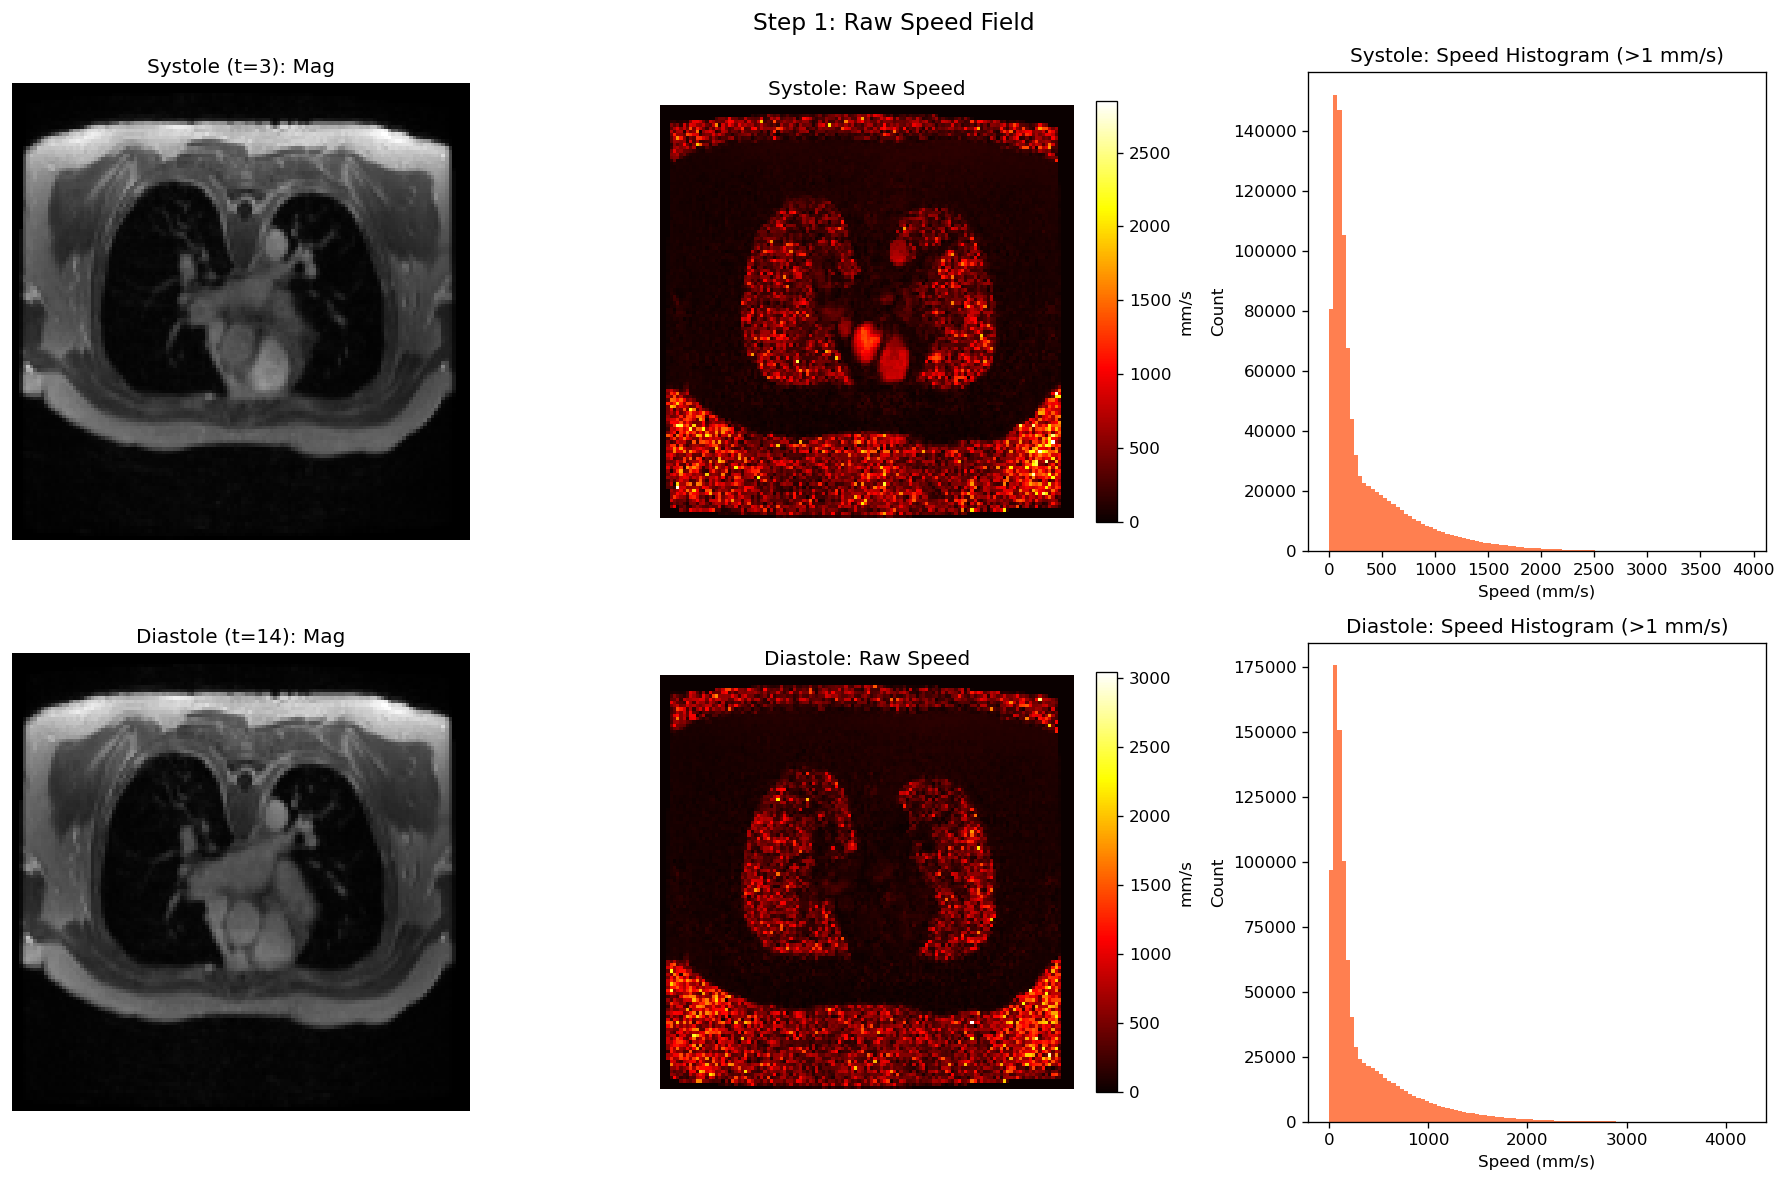

In [101]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for row, (mag, speed, label, tp) in enumerate([
    (mag_sys, speed_sys, 'Systole', SYSTOLIC_TP),
    (mag_dia, speed_dia, 'Diastole', DIASTOLIC_TP),
]):
    axes[row, 0].imshow(mag[0, :, :, AX_SLICE].T, cmap='gray', origin='lower')
    axes[row, 0].set_title(f'{label} (t={tp}): Mag')

    im = axes[row, 1].imshow(speed[0, :, :, AX_SLICE].T, cmap='hot', origin='lower')
    axes[row, 1].set_title(f'{label}: Raw Speed')
    plt.colorbar(im, ax=axes[row, 1], fraction=0.046, label='mm/s')

    # Histogram of nonzero speed values
    speed_flat = speed.flatten()
    speed_nonzero = speed_flat[speed_flat > 1.0]
    axes[row, 2].hist(speed_nonzero.numpy(), bins=100, color='coral', edgecolor='none')
    axes[row, 2].set_title(f'{label}: Speed Histogram (>1 mm/s)')
    axes[row, 2].set_xlabel('Speed (mm/s)')
    axes[row, 2].set_ylabel('Count')

for ax in axes[:, :2].flat:
    ax.axis('off')
plt.suptitle('Step 1: Raw Speed Field', fontsize=14)
plt.tight_layout()
plt.show()

---
## Step 2: Normalised Speed

Normalise speed to [0, 1]. Two options:
- Normalise by this timepoint's max speed
- Normalise by a fixed cap (e.g. 1.5 * VENC)

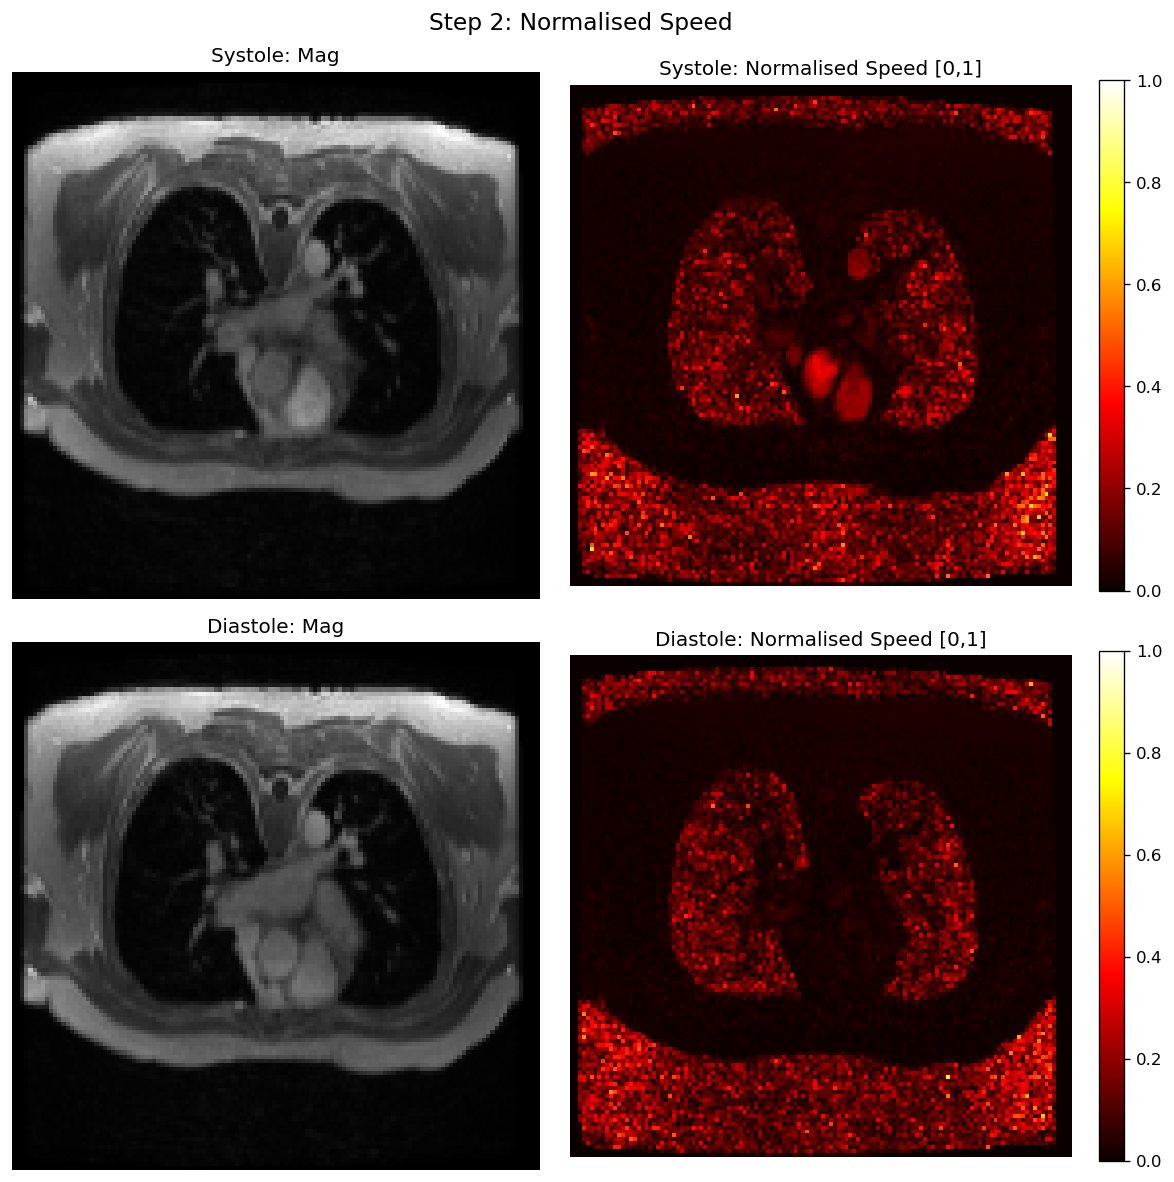

In [102]:
norm_speed_sys = speed_sys / (speed_sys.max() + 1e-8)
norm_speed_dia = speed_dia / (speed_dia.max() + 1e-8)

fig, axes = plt.subplots(2, 2, figsize=(10, 10))
for row, (mag, ns, label) in enumerate([
    (mag_sys, norm_speed_sys, 'Systole'),
    (mag_dia, norm_speed_dia, 'Diastole'),
]):
    axes[row, 0].imshow(mag[0, :, :, AX_SLICE].T, cmap='gray', origin='lower')
    axes[row, 0].set_title(f'{label}: Mag')
    im = axes[row, 1].imshow(ns[0, :, :, AX_SLICE].T, cmap='hot', origin='lower',
                              vmin=0, vmax=1)
    axes[row, 1].set_title(f'{label}: Normalised Speed [0,1]')
    plt.colorbar(im, ax=axes[row, 1], fraction=0.046)

for ax in axes.flat:
    ax.axis('off')
plt.suptitle('Step 2: Normalised Speed', fontsize=14)
plt.tight_layout()
plt.show()

---
## Step 3: Thresholded Speed Mask

Binary mask where normalised speed exceeds a threshold. Look at the raw
binary mask before any smoothing.

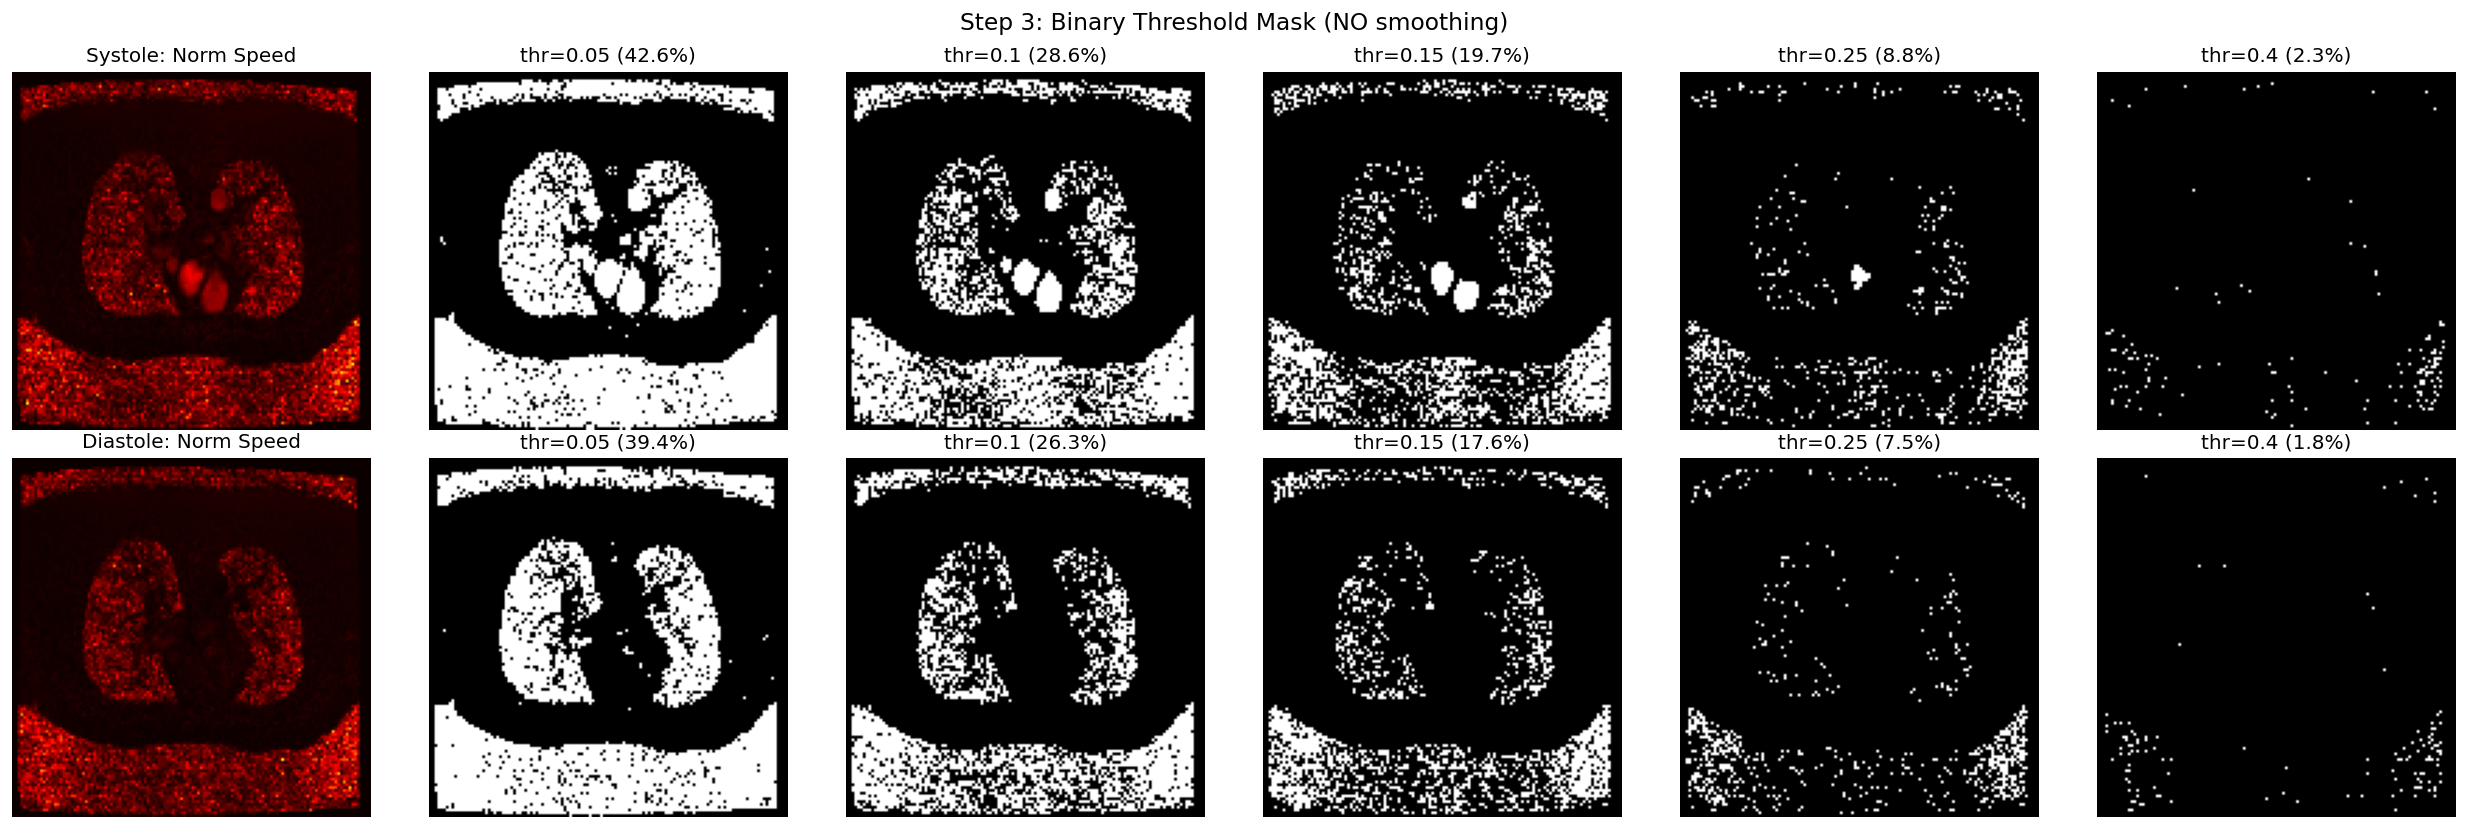

In [103]:
thresholds = [0.05, 0.10, 0.15, 0.25, 0.40]

fig, axes = plt.subplots(2, len(thresholds) + 1, figsize=(3.5 * (len(thresholds) + 1), 7))
for row, (ns, label) in enumerate([
    (norm_speed_sys, 'Systole'),
    (norm_speed_dia, 'Diastole'),
]):
    im = axes[row, 0].imshow(ns[0, :, :, AX_SLICE].T, cmap='hot', origin='lower',
                              vmin=0, vmax=1)
    axes[row, 0].set_title(f'{label}: Norm Speed')
    for j, thr in enumerate(thresholds):
        mask = (ns > thr).float()
        pct = mask.mean().item() * 100
        axes[row, j + 1].imshow(mask[0, :, :, AX_SLICE].T, cmap='gray', origin='lower')
        axes[row, j + 1].set_title(f'thr={thr} ({pct:.1f}%)')

for ax in axes.flat:
    ax.axis('off')
plt.suptitle('Step 3: Binary Threshold Mask (NO smoothing)', fontsize=14)
plt.tight_layout()
plt.show()

---
## Step 4: Effect of Gaussian Smoothing on Mask

Smooth the binary mask with different sigma values and see what happens.

In [104]:
def gaussian_smooth_3d(tensor, sigma=2.0):
    ks = int(6 * sigma + 1)
    if ks % 2 == 0:
        ks += 1
    x = torch.arange(ks, dtype=torch.float32, device=tensor.device) - ks // 2
    kernel_1d = torch.exp(-0.5 * (x / sigma) ** 2)
    kernel_1d = kernel_1d / kernel_1d.sum()

    t = tensor.unsqueeze(0) if tensor.dim() == 4 else tensor
    pad = ks // 2
    pad_configs = {
        2: [0, 0, 0, 0, pad, pad],
        3: [0, 0, pad, pad, 0, 0],
        4: [pad, pad, 0, 0, 0, 0],
    }
    for dim in [2, 3, 4]:
        t = torch.nn.functional.pad(t, pad_configs[dim], mode='replicate')
        weight = torch.zeros(1, 1, ks if dim == 2 else 1,
                             ks if dim == 3 else 1,
                             ks if dim == 4 else 1, device=tensor.device)
        if dim == 2:
            weight[0, 0, :, 0, 0] = kernel_1d
        elif dim == 3:
            weight[0, 0, 0, :, 0] = kernel_1d
        else:
            weight[0, 0, 0, 0, :] = kernel_1d
        t = torch.nn.functional.conv3d(t, weight, padding=0)
    return t.squeeze(0) if tensor.dim() == 4 else t

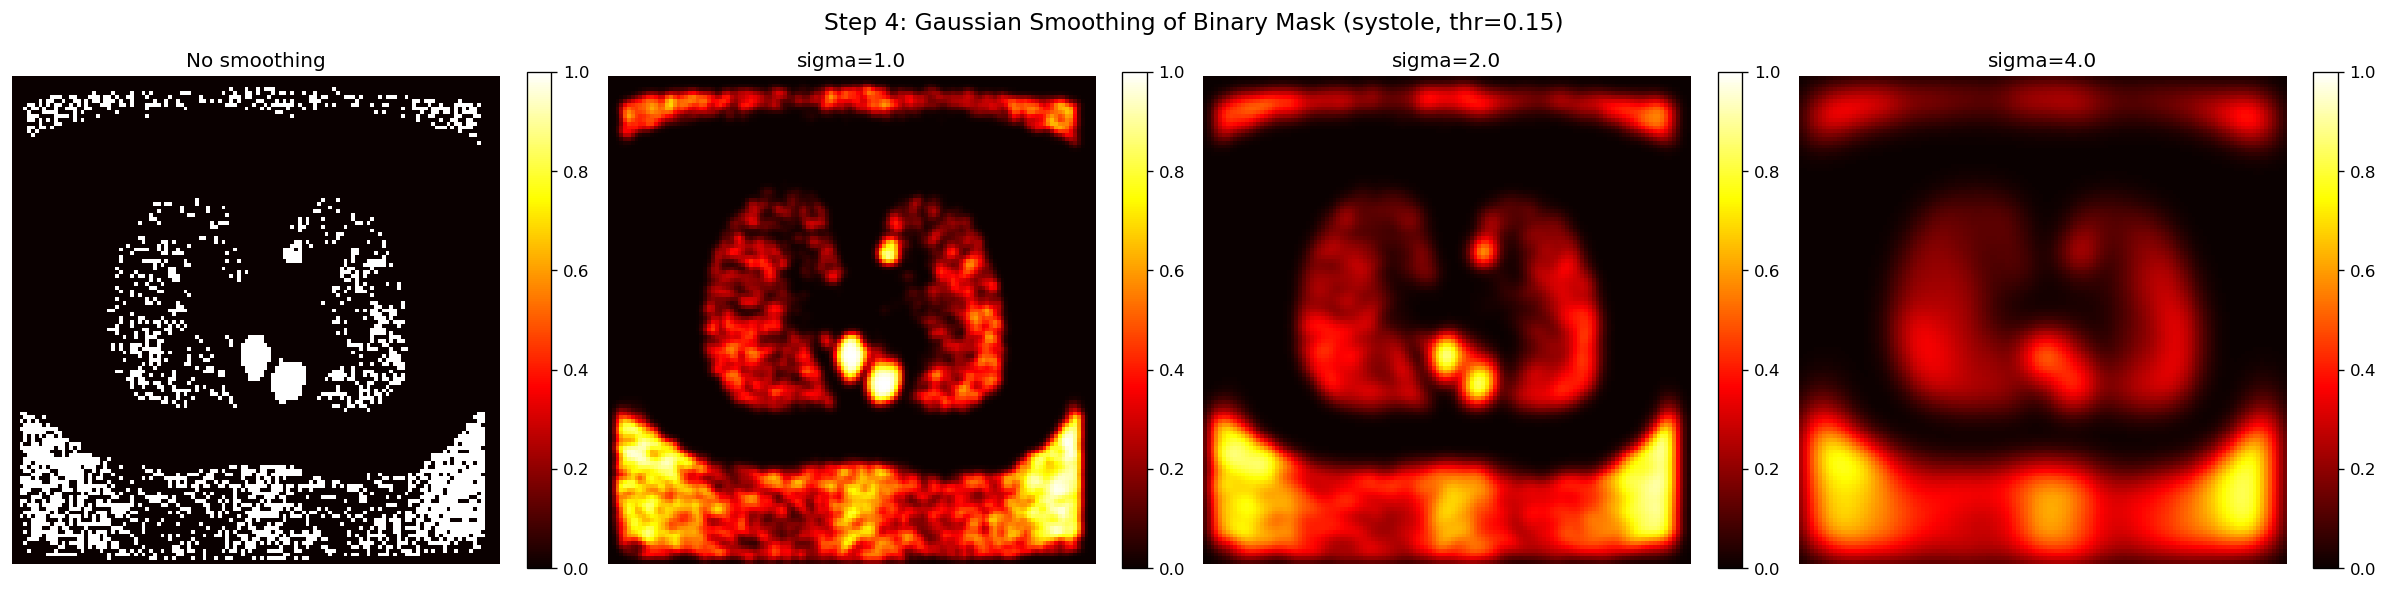

In [105]:
thr = 0.15
sigmas = [0, 1.0, 2.0, 4.0]
mask_raw = (norm_speed_sys > thr).float()

fig, axes = plt.subplots(1, len(sigmas), figsize=(5 * len(sigmas), 5))
for j, sigma in enumerate(sigmas):
    if sigma == 0:
        mask = mask_raw
        title = f'No smoothing'
    else:
        mask = gaussian_smooth_3d(mask_raw, sigma=sigma)
        title = f'sigma={sigma}'
    im = axes[j].imshow(mask[0, :, :, AX_SLICE].T, cmap='hot', origin='lower',
                         vmin=0, vmax=1)
    axes[j].set_title(title)
    axes[j].axis('off')
    plt.colorbar(im, ax=axes[j], fraction=0.046)
plt.suptitle(f'Step 4: Gaussian Smoothing of Binary Mask (systole, thr={thr})', fontsize=14)
plt.tight_layout()
plt.show()

---
## Step 5: The Inversion Itself

Now apply the inversion step by step. Show what `1.0 - mag` looks like,
what the alpha-blended result looks like, and inspect what happens at
different mag values.

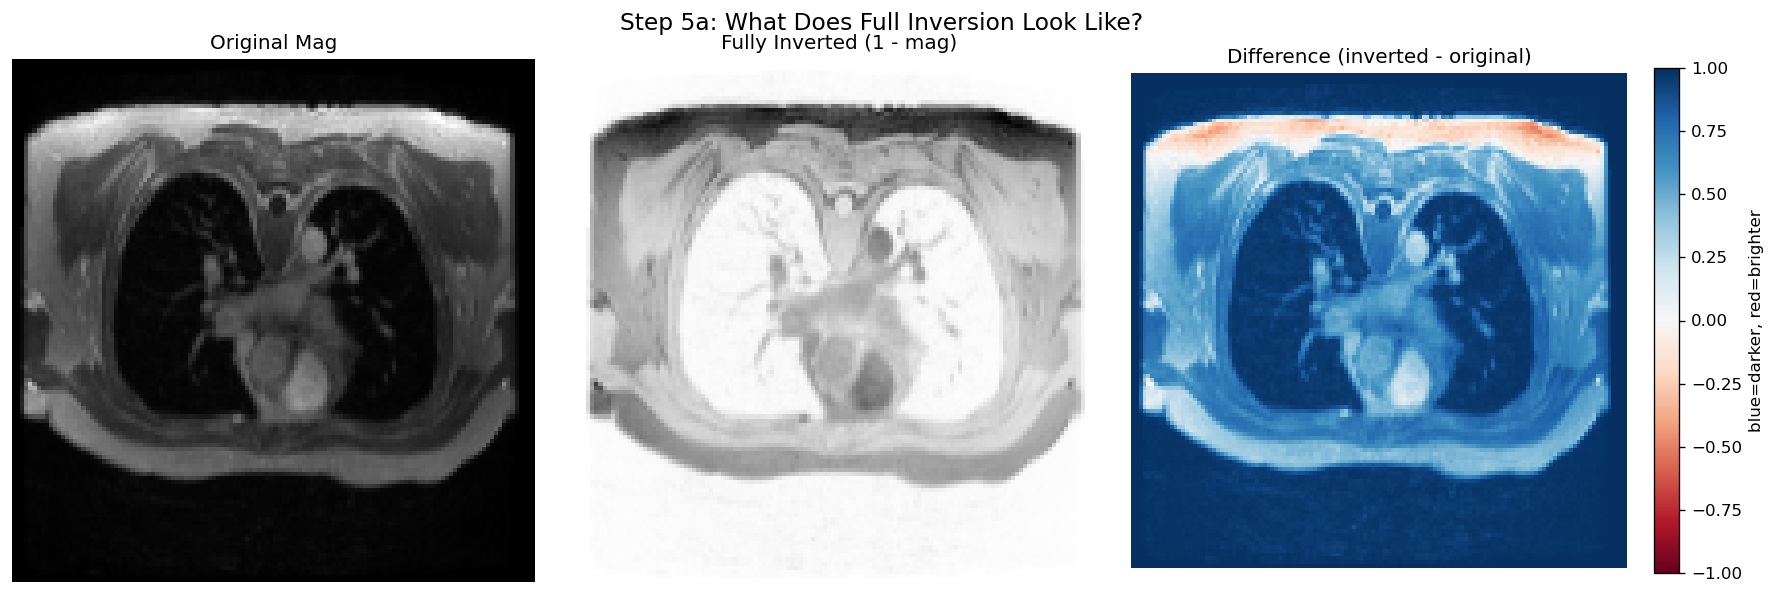

In [106]:
inverted_sys = 1.0 - mag_sys

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(mag_sys[0, :, :, AX_SLICE].T, cmap='gray', origin='lower')
axes[0].set_title('Original Mag')
axes[1].imshow(inverted_sys[0, :, :, AX_SLICE].T, cmap='gray', origin='lower')
axes[1].set_title('Fully Inverted (1 - mag)')

# Show the difference
diff = (inverted_sys - mag_sys)
im = axes[2].imshow(diff[0, :, :, AX_SLICE].T, cmap='RdBu', origin='lower',
                     vmin=-1, vmax=1)
axes[2].set_title('Difference (inverted - original)')
plt.colorbar(im, ax=axes[2], fraction=0.046, label='blue=darker, red=brighter')

for ax in axes:
    ax.axis('off')
plt.suptitle('Step 5a: What Does Full Inversion Look Like?', fontsize=14)
plt.tight_layout()
plt.show()

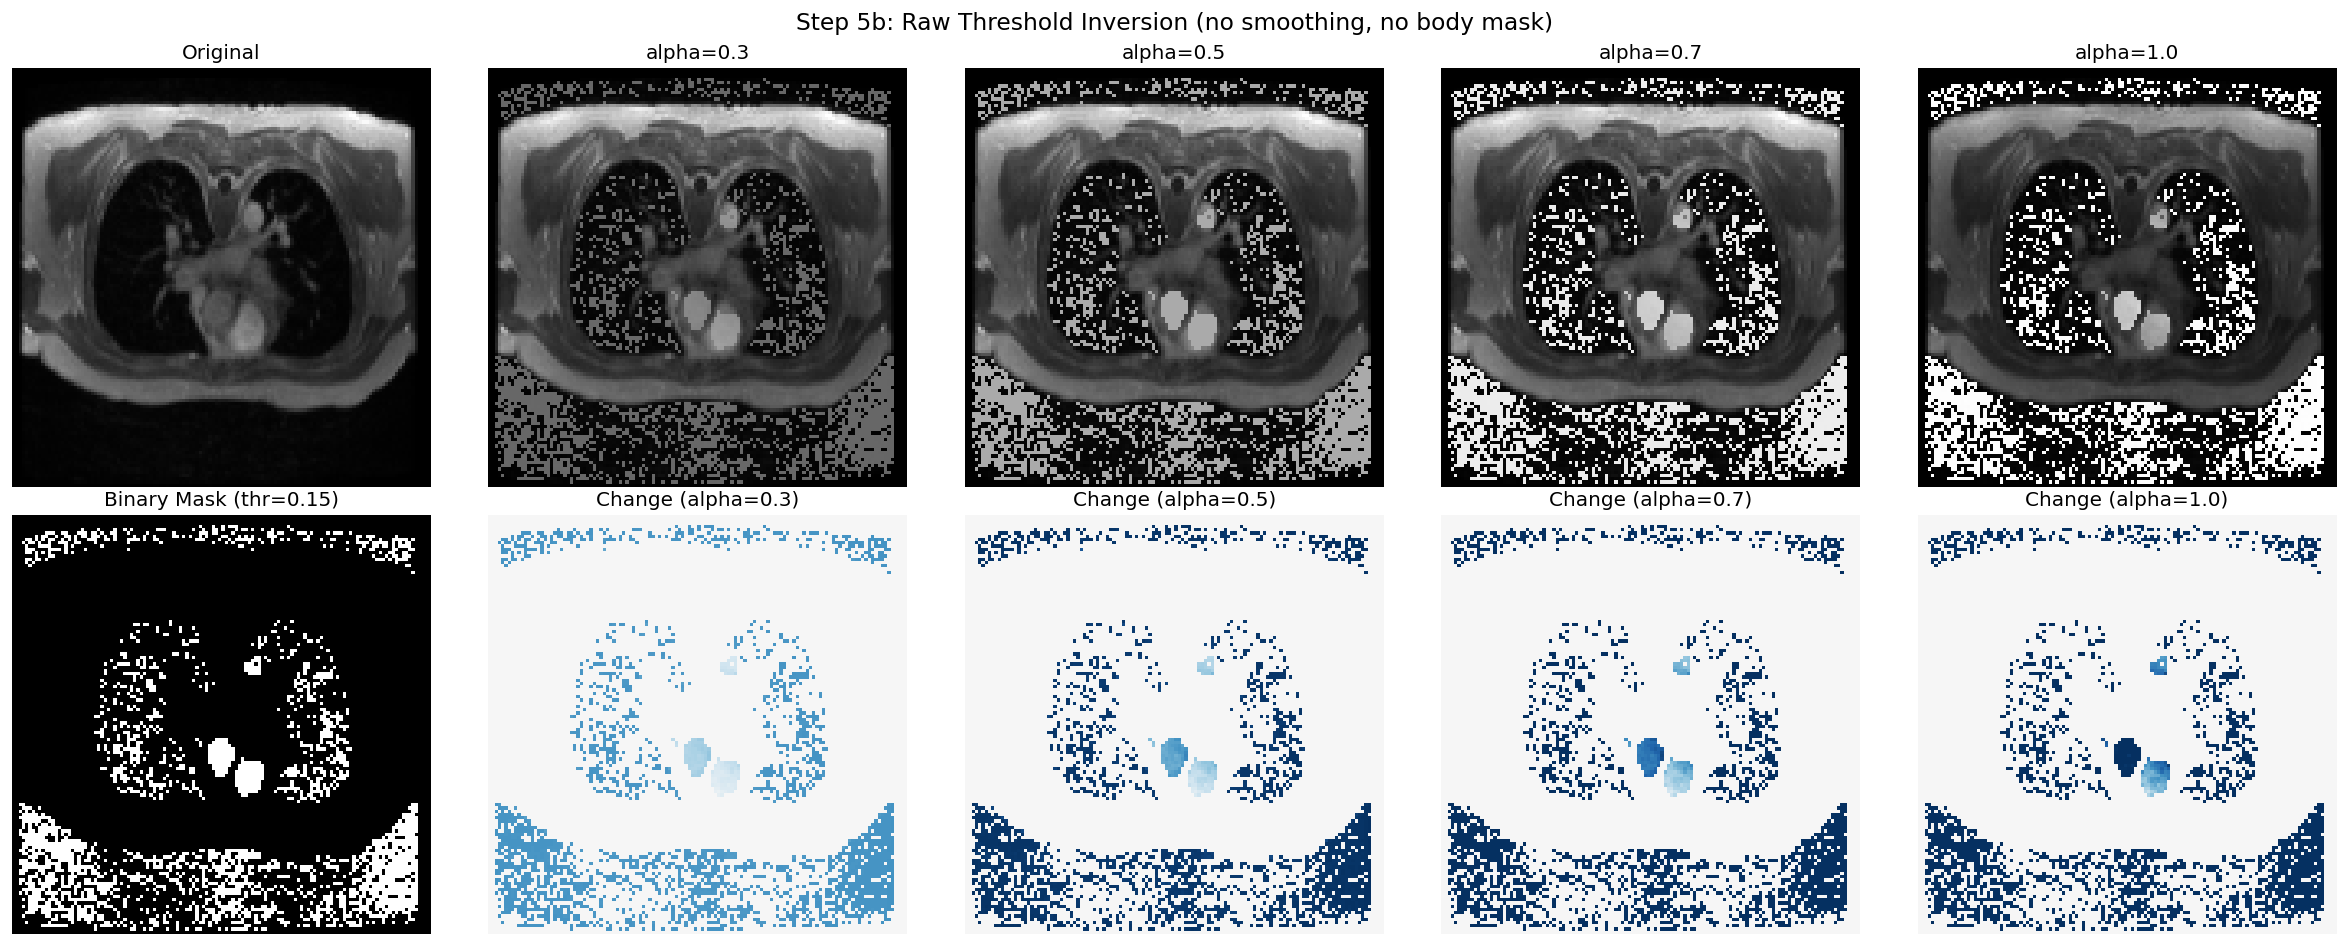

In [107]:
# Now apply the mask at different alpha values - NO smoothing, NO body mask
# Just raw threshold + inversion to see the pure effect
thr = 0.15
mask = (norm_speed_sys > thr).float()
alphas = [0.3, 0.5, 0.7, 1.0]

fig, axes = plt.subplots(2, len(alphas) + 1, figsize=(4 * (len(alphas) + 1), 8))

axes[0, 0].imshow(mag_sys[0, :, :, AX_SLICE].T, cmap='gray', origin='lower')
axes[0, 0].set_title('Original')
axes[1, 0].imshow(mask[0, :, :, AX_SLICE].T, cmap='gray', origin='lower')
axes[1, 0].set_title(f'Binary Mask (thr={thr})')

for j, alpha in enumerate(alphas):
    result = mag_sys * (1 - mask * alpha) + inverted_sys * (mask * alpha)
    axes[0, j + 1].imshow(result[0, :, :, AX_SLICE].T, cmap='gray', origin='lower')
    axes[0, j + 1].set_title(f'alpha={alpha}')

    # Show what changed
    change = result - mag_sys
    im = axes[1, j + 1].imshow(change[0, :, :, AX_SLICE].T, cmap='RdBu', origin='lower',
                                vmin=-0.5, vmax=0.5)
    axes[1, j + 1].set_title(f'Change (alpha={alpha})')

for ax in axes.flat:
    ax.axis('off')
plt.suptitle('Step 5b: Raw Threshold Inversion (no smoothing, no body mask)', fontsize=14)
plt.tight_layout()
plt.show()

---
## Step 5c: Body-Masked Global Inversion

Invert the entire image (`1 - mag`) but only for voxels above the air
threshold. Air stays at its original value.

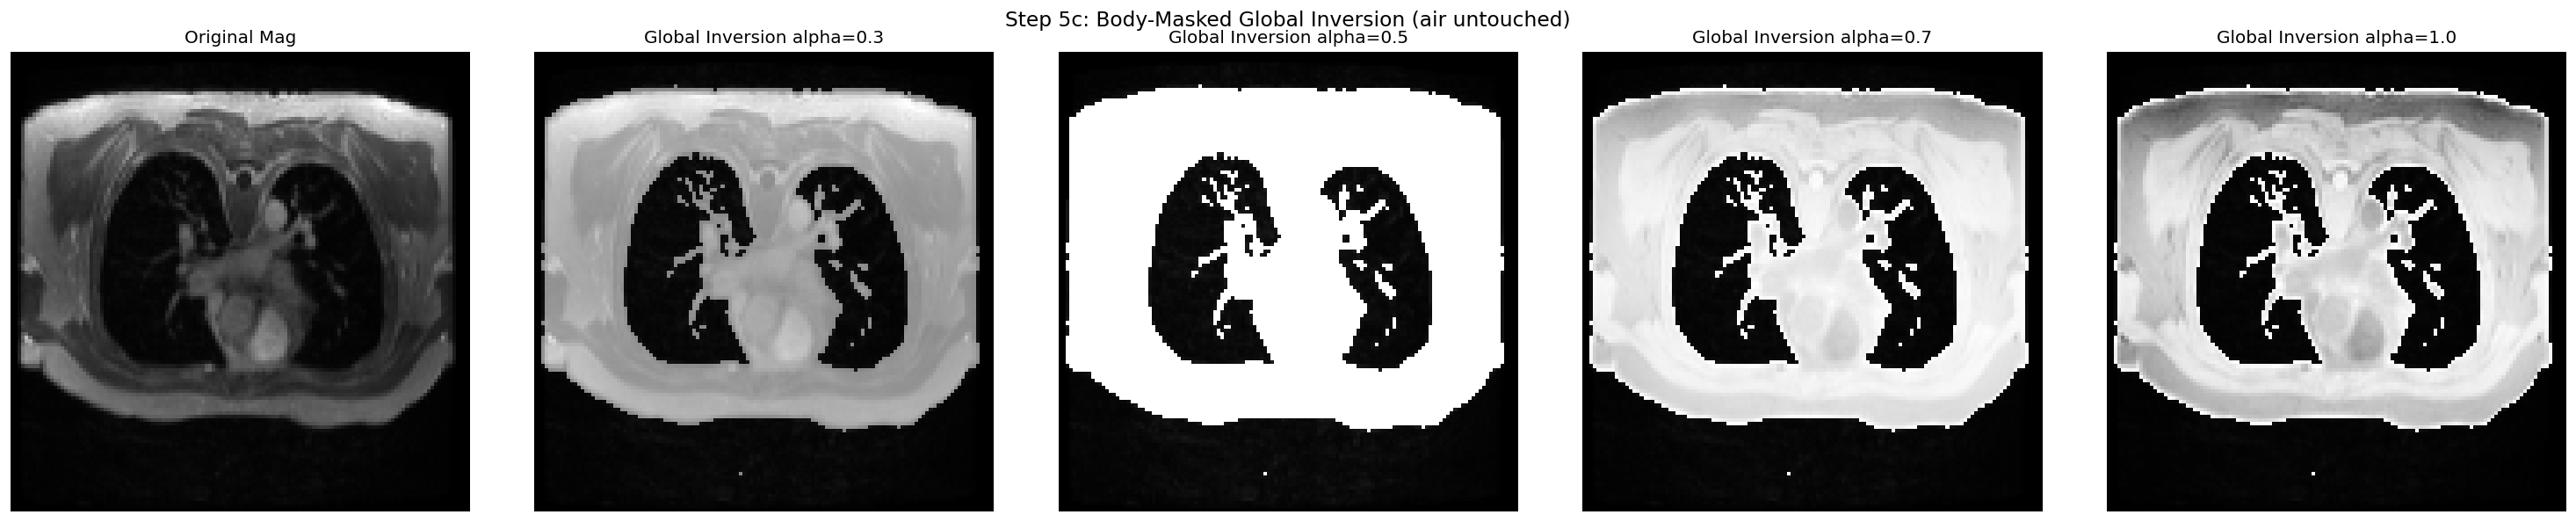

In [108]:
body = (mag_sys > 0.05).float()
inverted = 1.0 - mag_sys
alphas = [0.3, 0.5, 0.7, 1.0]

fig, axes = plt.subplots(1, len(alphas) + 1, figsize=(5 * (len(alphas) + 1), 5))
axes[0].imshow(mag_sys[0, :, :, AX_SLICE].T, cmap='gray', origin='lower')
axes[0].set_title('Original Mag')

for j, alpha in enumerate(alphas):
    result = mag_sys * (1 - body * alpha) + inverted * (body * alpha)
    axes[j + 1].imshow(result[0, :, :, AX_SLICE].T, cmap='gray', origin='lower')
    axes[j + 1].set_title(f'Global Inversion alpha={alpha}')

for ax in axes:
    ax.axis('off')
plt.suptitle('Step 5c: Body-Masked Global Inversion (air untouched)', fontsize=14)
plt.tight_layout()
plt.show()

---
## Step 6: Speed-Guided Contrast Removal (Attenuation, Not Inversion)

Instead of inverting (`1 - mag`), we **attenuate** blood signal using the speed
field as a mask. Three approaches:

1. **Simple attenuation**: multiply blood signal down (darker blood)
2. **Blend toward local tissue mean**: blood becomes tissue-coloured
3. **Blend toward dark**: blood becomes darker than tissue (non-contrast look)

All leave non-blood tissue untouched.

Speed mask range: [0.000, 0.369]
Tissue mean range: [0.000, 0.327]


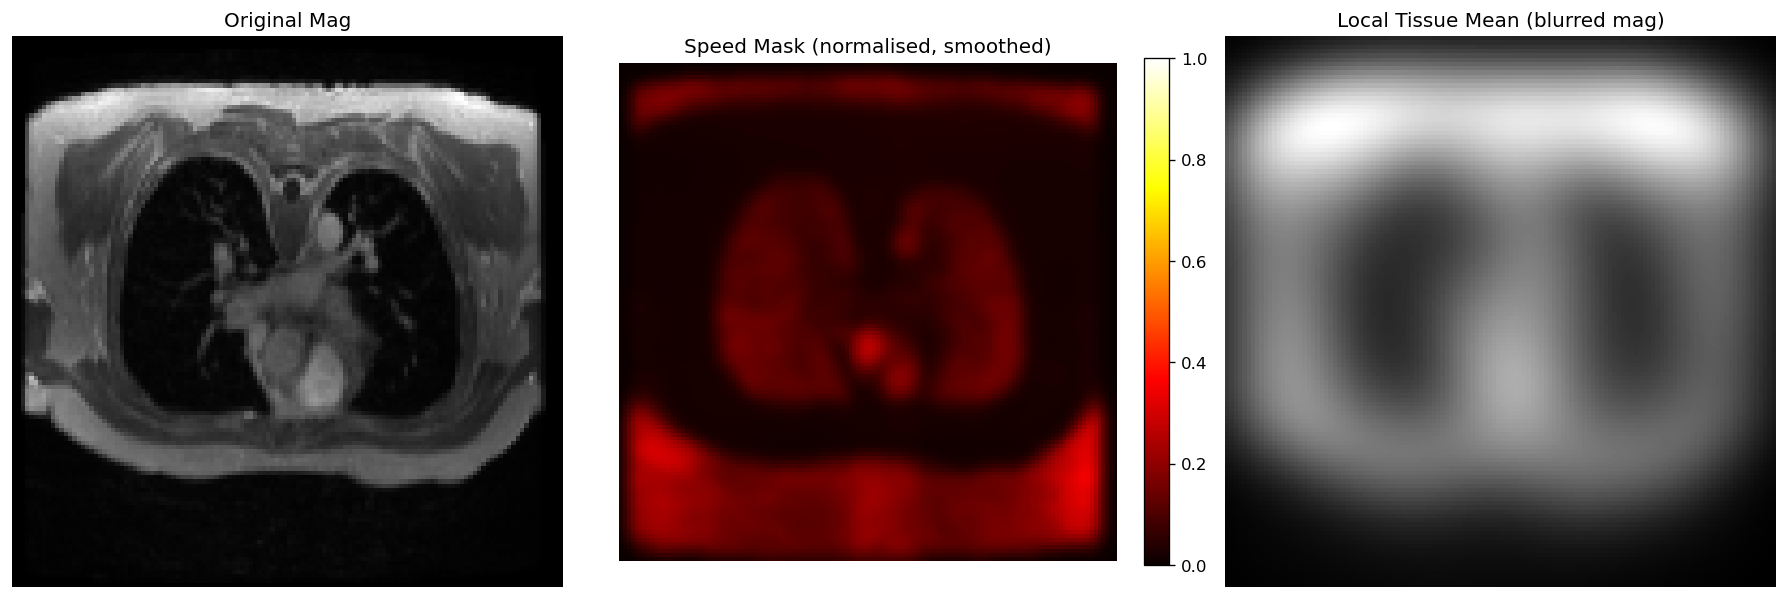

In [109]:
def compute_speed_mask(speed, speed_cap=None, smooth_sigma=2.0):
    """Normalise speed to [0,1] and optionally smooth."""
    if speed_cap is None:
        speed_cap = speed.max()
    mask = (speed / (speed_cap + 1e-8)).clamp(0, 1)
    if smooth_sigma > 0:
        mask = gaussian_smooth_3d(mask, sigma=smooth_sigma)
    return mask


def local_tissue_mean(mag, kernel_sigma=8.0):
    """Heavily blurred mag as an estimate of local tissue intensity."""
    return gaussian_smooth_3d(mag, sigma=kernel_sigma)


# Compute the speed mask from systolic data
speed_mask_sys = compute_speed_mask(speed_sys, smooth_sigma=2.0)
tissue_mean_sys = local_tissue_mean(mag_sys, kernel_sigma=8.0)

print(f"Speed mask range: [{speed_mask_sys.min():.3f}, {speed_mask_sys.max():.3f}]")
print(f"Tissue mean range: [{tissue_mean_sys.min():.3f}, {tissue_mean_sys.max():.3f}]")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(mag_sys[0, :, :, AX_SLICE].T, cmap='gray', origin='lower')
axes[0].set_title('Original Mag')
im1 = axes[1].imshow(speed_mask_sys[0, :, :, AX_SLICE].T, cmap='hot', origin='lower', vmin=0, vmax=1)
axes[1].set_title('Speed Mask (normalised, smoothed)')
plt.colorbar(im1, ax=axes[1], fraction=0.046)
axes[2].imshow(tissue_mean_sys[0, :, :, AX_SLICE].T, cmap='gray', origin='lower')
axes[2].set_title('Local Tissue Mean (blurred mag)')
for ax in axes:
    ax.axis('off')
plt.tight_layout()
plt.show()

### Approach A: Simple Attenuation

`result = mag * (1 - alpha * speed_mask)`

Blood signal is multiplied down. At alpha=1.0, blood voxels with high speed
go to near zero. This simulates the non-contrast "dark blood" look.

=== Speed mask stats ===
Shape: torch.Size([1, 128, 128, 64])
Range: [0.0000, 0.3686]
Mean: 0.0854
Nonzero (>0.01) mean: 0.0871, median: 0.0561
  50th percentile of nonzero: 0.0561
  75th percentile of nonzero: 0.1342
  90th percentile of nonzero: 0.1990
  95th percentile of nonzero: 0.2329
  99th percentile of nonzero: 0.2992

Raw speed nonzero (>10 mm/s): 984783 voxels
10th percentile cap: 49.3 mm/s
25th percentile cap: 86.3 mm/s
Max speed: 3917.2 mm/s


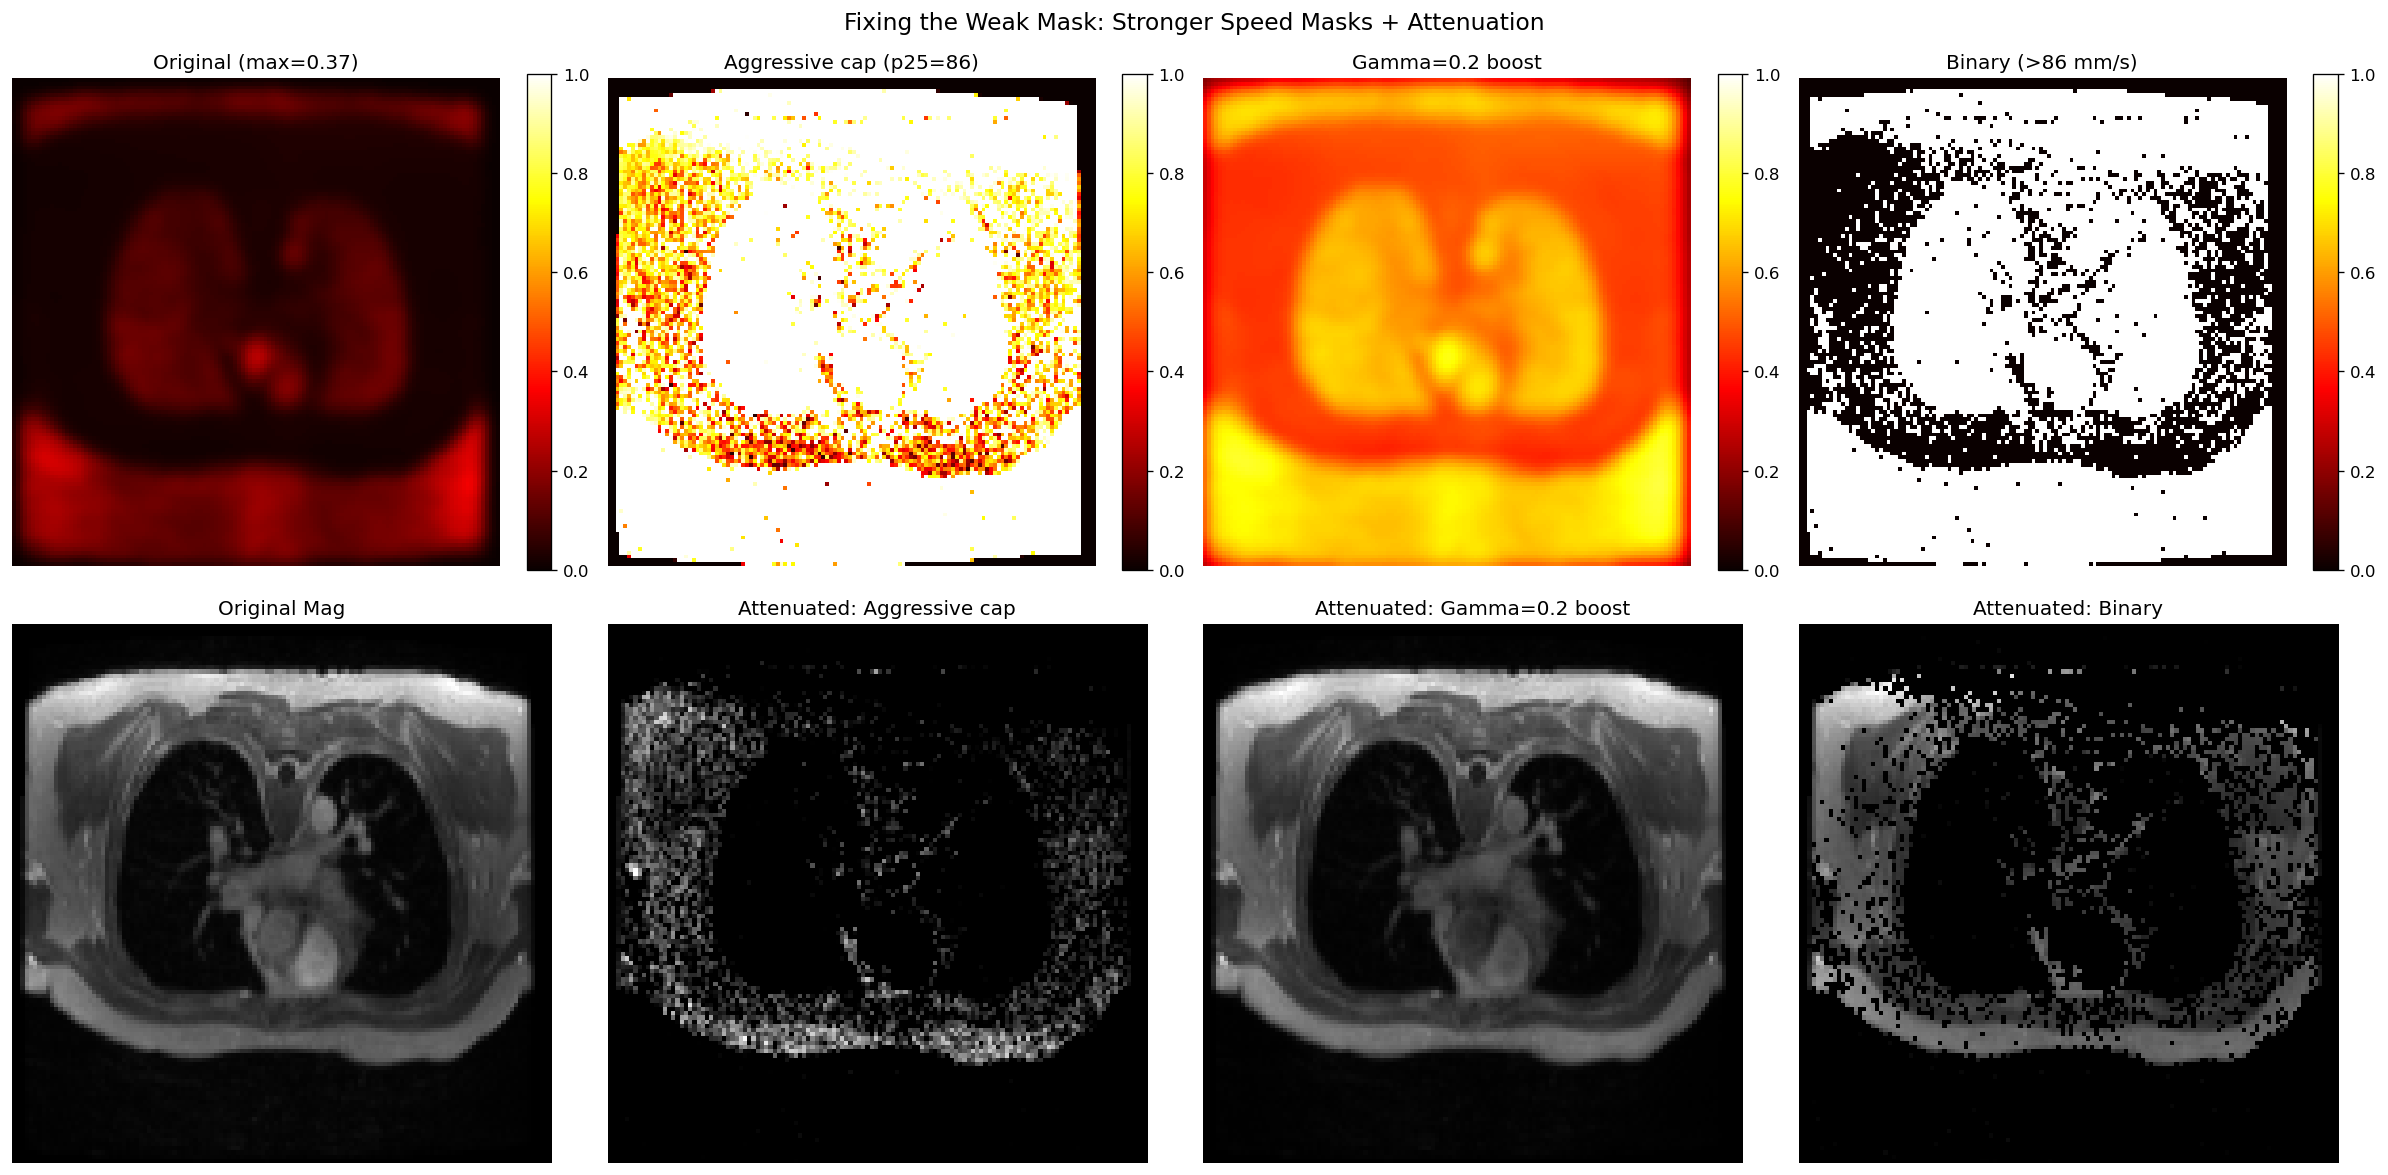

In [110]:
# Diagnose why the mask is too weak
print("=== Speed mask stats ===")
print(f"Shape: {speed_mask_sys.shape}")
print(f"Range: [{speed_mask_sys.min():.4f}, {speed_mask_sys.max():.4f}]")
print(f"Mean: {speed_mask_sys.mean():.4f}")
nonzero = speed_mask_sys[speed_mask_sys > 0.01]
if len(nonzero) > 0:
    print(f"Nonzero (>0.01) mean: {nonzero.mean():.4f}, median: {nonzero.median():.4f}")
    for pct in [50, 75, 90, 95, 99]:
        print(f"  {pct}th percentile of nonzero: {torch.quantile(nonzero, pct/100):.4f}")

# The mask is way too weak. Try much stronger masks:
# 1. Cap at a low percentile so blood pool saturates to 1
# 2. Apply gamma < 1 to boost mid-range values
# 3. Binary threshold

# Use raw (un-smoothed) speed for comparison
raw_norm = (speed_sys / (speed_sys.max() + 1e-8)).clamp(0, 1)

# Aggressive cap: use 10th percentile of nonzero as cap
nonzero_speed = speed_sys[speed_sys > 10.0]
pct10_cap = torch.quantile(nonzero_speed, 0.10).item()
pct25_cap = torch.quantile(nonzero_speed, 0.25).item()
print(f"\nRaw speed nonzero (>10 mm/s): {len(nonzero_speed)} voxels")
print(f"10th percentile cap: {pct10_cap:.1f} mm/s")
print(f"25th percentile cap: {pct25_cap:.1f} mm/s")
print(f"Max speed: {speed_sys.max():.1f} mm/s")

mask_aggressive = (speed_sys / (pct25_cap + 1e-8)).clamp(0, 1)
mask_gamma = speed_mask_sys ** 0.2  # gamma boost
mask_binary = (speed_sys > pct25_cap).float()

fig, axes = plt.subplots(2, 4, figsize=(20, 10))

# Row 1: masks
masks_to_show = [
    (speed_mask_sys, f'Original (max={speed_mask_sys.max():.2f})'),
    (mask_aggressive, f'Aggressive cap (p25={pct25_cap:.0f})'),
    (mask_gamma, 'Gamma=0.2 boost'),
    (mask_binary, f'Binary (>{pct25_cap:.0f} mm/s)'),
]
for j, (m, title) in enumerate(masks_to_show):
    im = axes[0, j].imshow(m[0, :, :, AX_SLICE].T, cmap='hot', origin='lower', vmin=0, vmax=1)
    axes[0, j].set_title(title)
    plt.colorbar(im, ax=axes[0, j], fraction=0.046)

# Row 2: attenuation results using each mask (alpha=1)
axes[1, 0].imshow(mag_sys[0, :, :, AX_SLICE].T, cmap='gray', origin='lower')
axes[1, 0].set_title('Original Mag')
for j, (m, title) in enumerate(masks_to_show[1:]):
    result = mag_sys * (1 - m)
    axes[1, j + 1].imshow(result[0, :, :, AX_SLICE].T, cmap='gray', origin='lower')
    axes[1, j + 1].set_title(f'Attenuated: {title.split("(")[0].strip()}')

for ax in axes.flat:
    ax.axis('off')
plt.suptitle('Fixing the Weak Mask: Stronger Speed Masks + Attenuation', fontsize=14)
plt.tight_layout()
plt.show()

---
## Step 7: Better Blood Masks Using Speed + Magnitude

Speed alone is too noisy. But in contrast-enhanced images, blood has both
high speed AND high magnitude. Combine them to isolate blood from tissue noise.

Strategies:
- **Multiply**: `speed_norm * mag` - blood is bright on both, noise is bright on speed but dark on mag
- **AND threshold**: `(speed > S) AND (mag > M)` - binary conjunction
- **Product threshold**: threshold on `speed * mag`

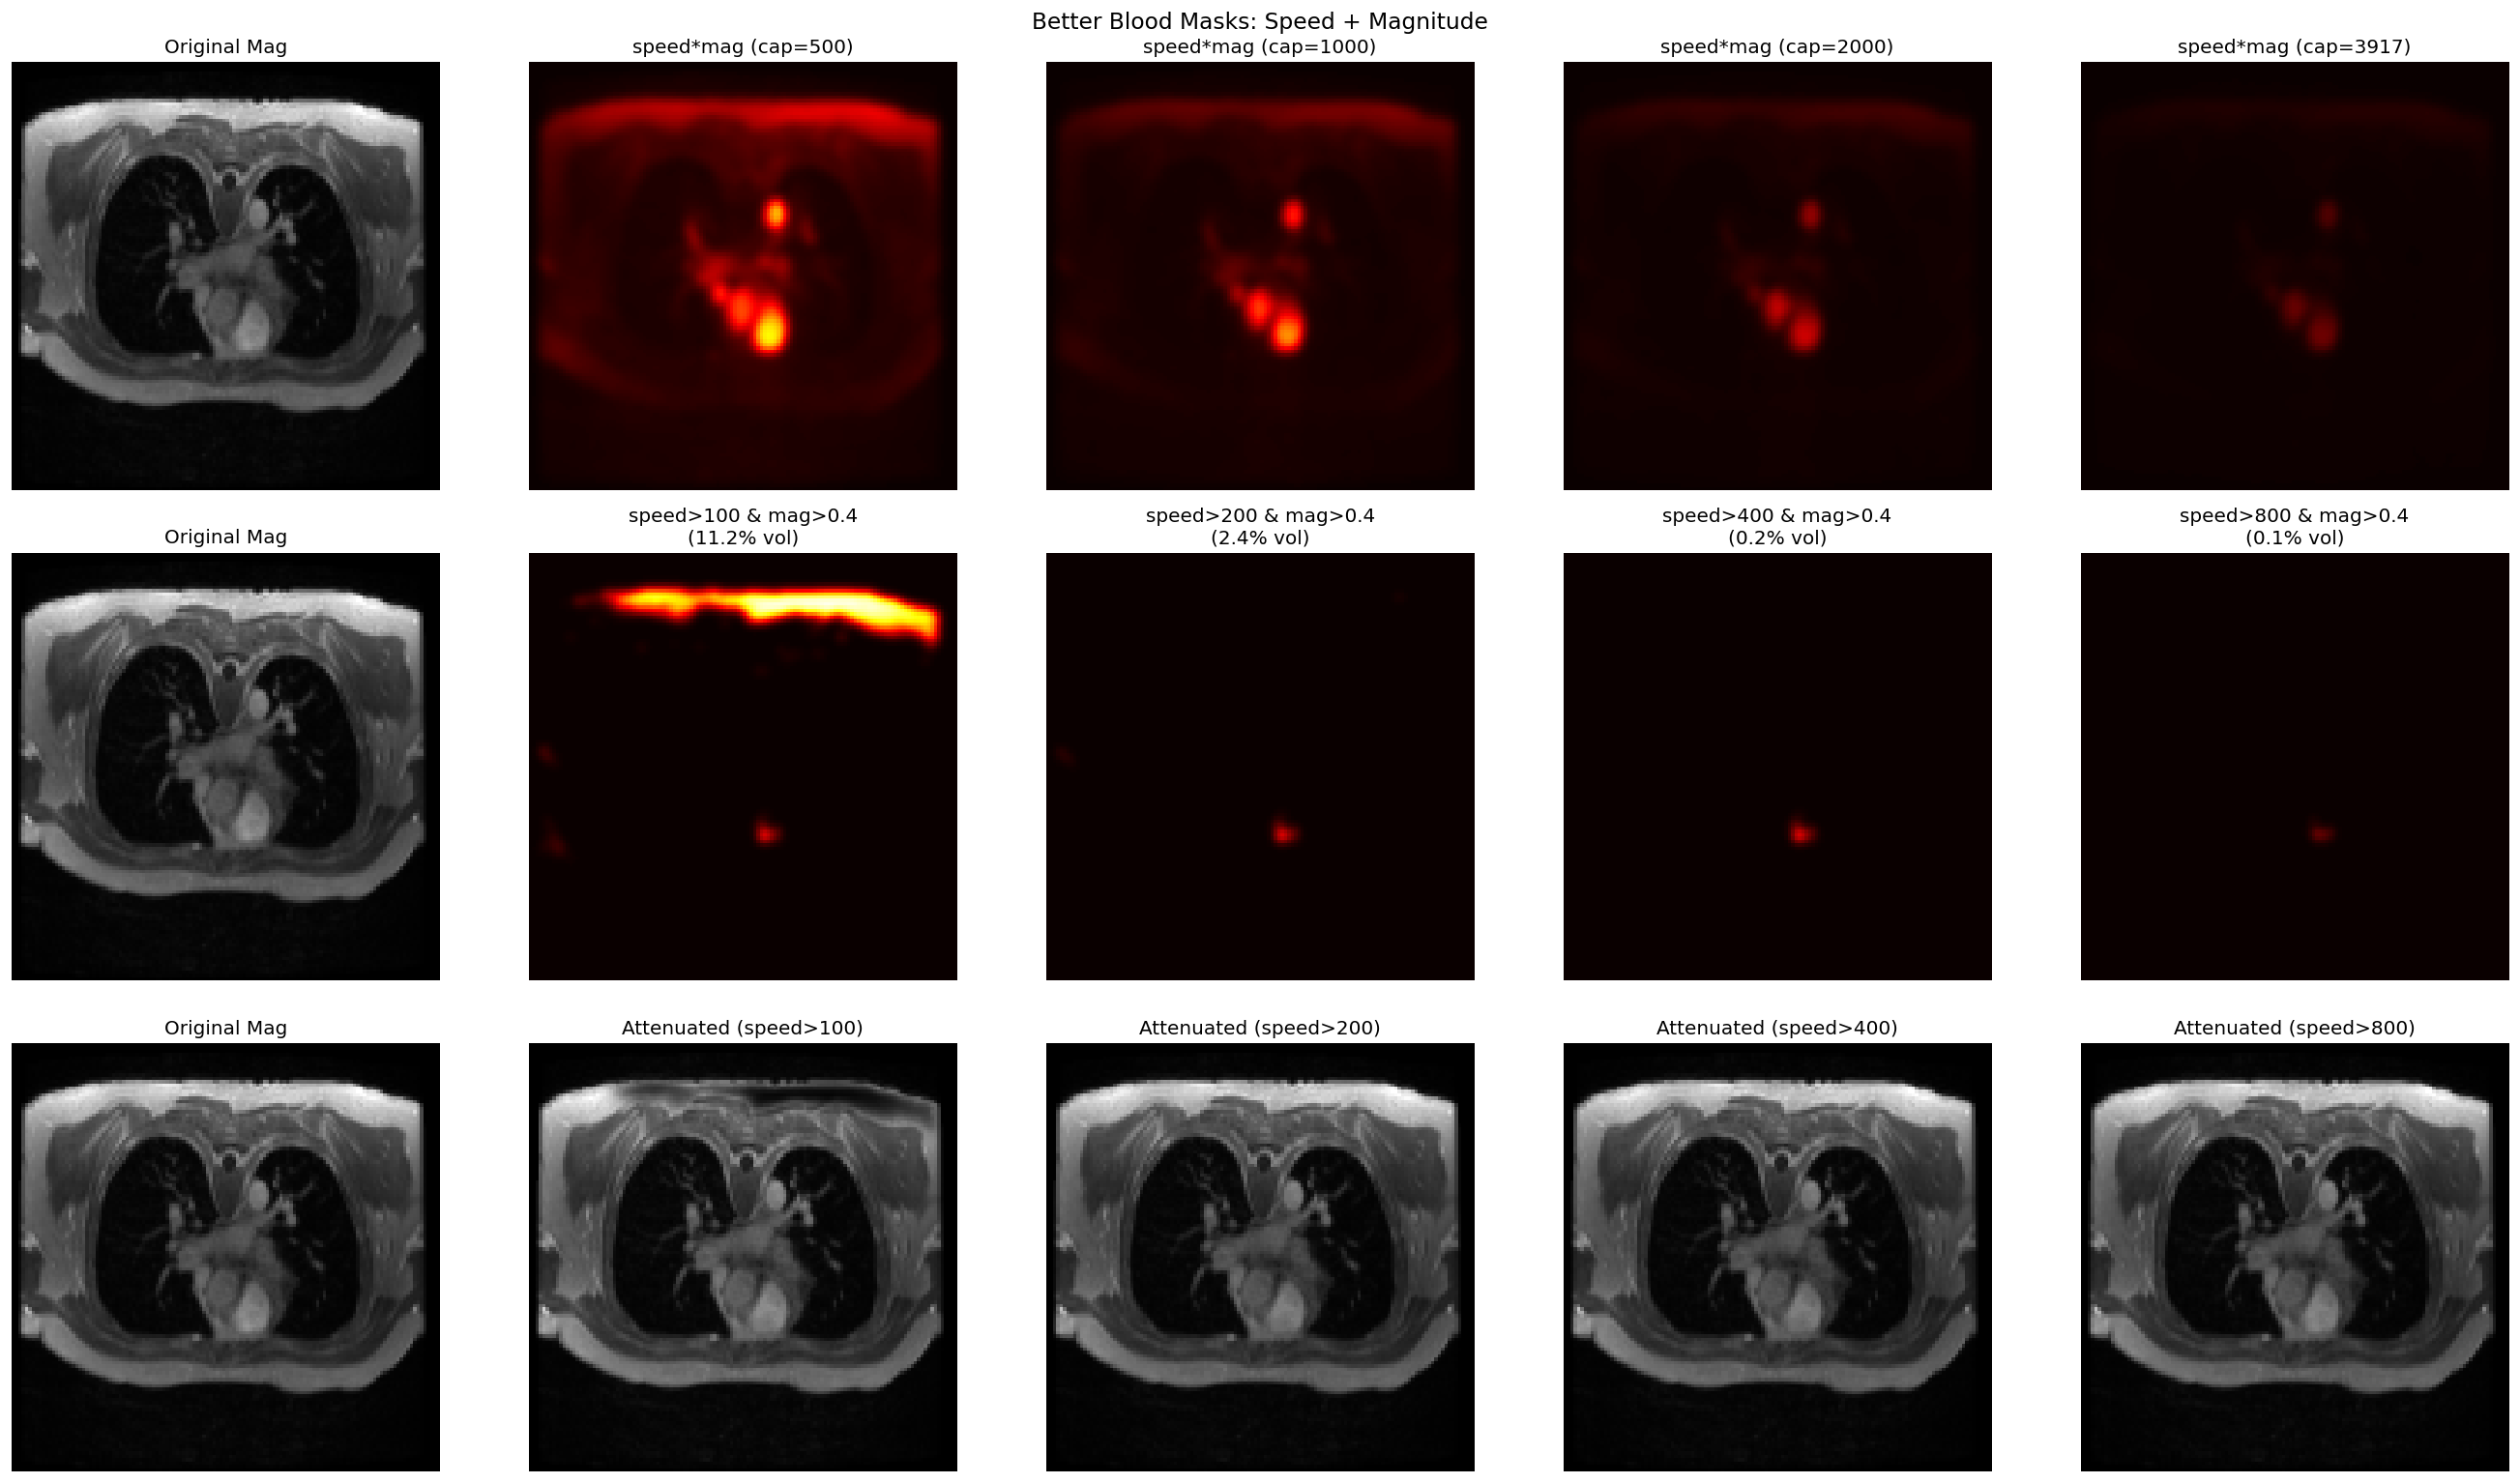

In [111]:
# Normalise speed to [0,1] using max (raw, no smoothing yet)
speed_norm = (speed_sys / (speed_sys.max() + 1e-8)).clamp(0, 1)

# Strategy 1: Multiply speed_norm * mag
product_mask = speed_norm * mag_sys

# Strategy 2: AND threshold at various levels
# For speed: use a high threshold to cut above noise floor
# For mag: use a moderate threshold to select bright blood
speed_thresholds_mmps = [100, 200, 400, 800]
mag_threshold = 0.4

fig, axes = plt.subplots(3, len(speed_thresholds_mmps) + 1, 
                          figsize=(4.5 * (len(speed_thresholds_mmps) + 1), 13))

# Row 0: product mask at different normalisation caps
axes[0, 0].imshow(mag_sys[0, :, :, AX_SLICE].T, cmap='gray', origin='lower')
axes[0, 0].set_title('Original Mag')
for j, cap in enumerate([500, 1000, 2000, 3917]):
    pm = (speed_sys / cap).clamp(0, 1) * mag_sys
    pm = gaussian_smooth_3d(pm, sigma=1.5)
    im = axes[0, j + 1].imshow(pm[0, :, :, AX_SLICE].T, cmap='hot', origin='lower', vmin=0, vmax=0.5)
    axes[0, j + 1].set_title(f'speed*mag (cap={cap})')

# Row 1: AND threshold masks
axes[1, 0].imshow(mag_sys[0, :, :, AX_SLICE].T, cmap='gray', origin='lower')
axes[1, 0].set_title(f'Original Mag')
for j, st in enumerate(speed_thresholds_mmps):
    and_mask = ((speed_sys > st) & (mag_sys > mag_threshold)).float()
    and_mask = gaussian_smooth_3d(and_mask, sigma=1.5)
    pct = (and_mask > 0.01).float().mean().item() * 100
    im = axes[1, j + 1].imshow(and_mask[0, :, :, AX_SLICE].T, cmap='hot', origin='lower', vmin=0, vmax=1)
    axes[1, j + 1].set_title(f'speed>{st} & mag>{mag_threshold}\n({pct:.1f}% vol)')

# Row 2: attenuation using each AND mask
axes[2, 0].imshow(mag_sys[0, :, :, AX_SLICE].T, cmap='gray', origin='lower')
axes[2, 0].set_title('Original Mag')
for j, st in enumerate(speed_thresholds_mmps):
    and_mask = ((speed_sys > st) & (mag_sys > mag_threshold)).float()
    and_mask = gaussian_smooth_3d(and_mask, sigma=1.5)
    result = mag_sys * (1 - and_mask)
    axes[2, j + 1].imshow(result[0, :, :, AX_SLICE].T, cmap='gray', origin='lower')
    axes[2, j + 1].set_title(f'Attenuated (speed>{st})')

for ax in axes.flat:
    ax.axis('off')
plt.suptitle('Better Blood Masks: Speed + Magnitude', fontsize=14)
plt.tight_layout()
plt.show()

### Apply Attenuation with Best Mask

Pick the best-looking mask from above, then sweep attenuation targets
(dark blood to tissue-coloured blood).

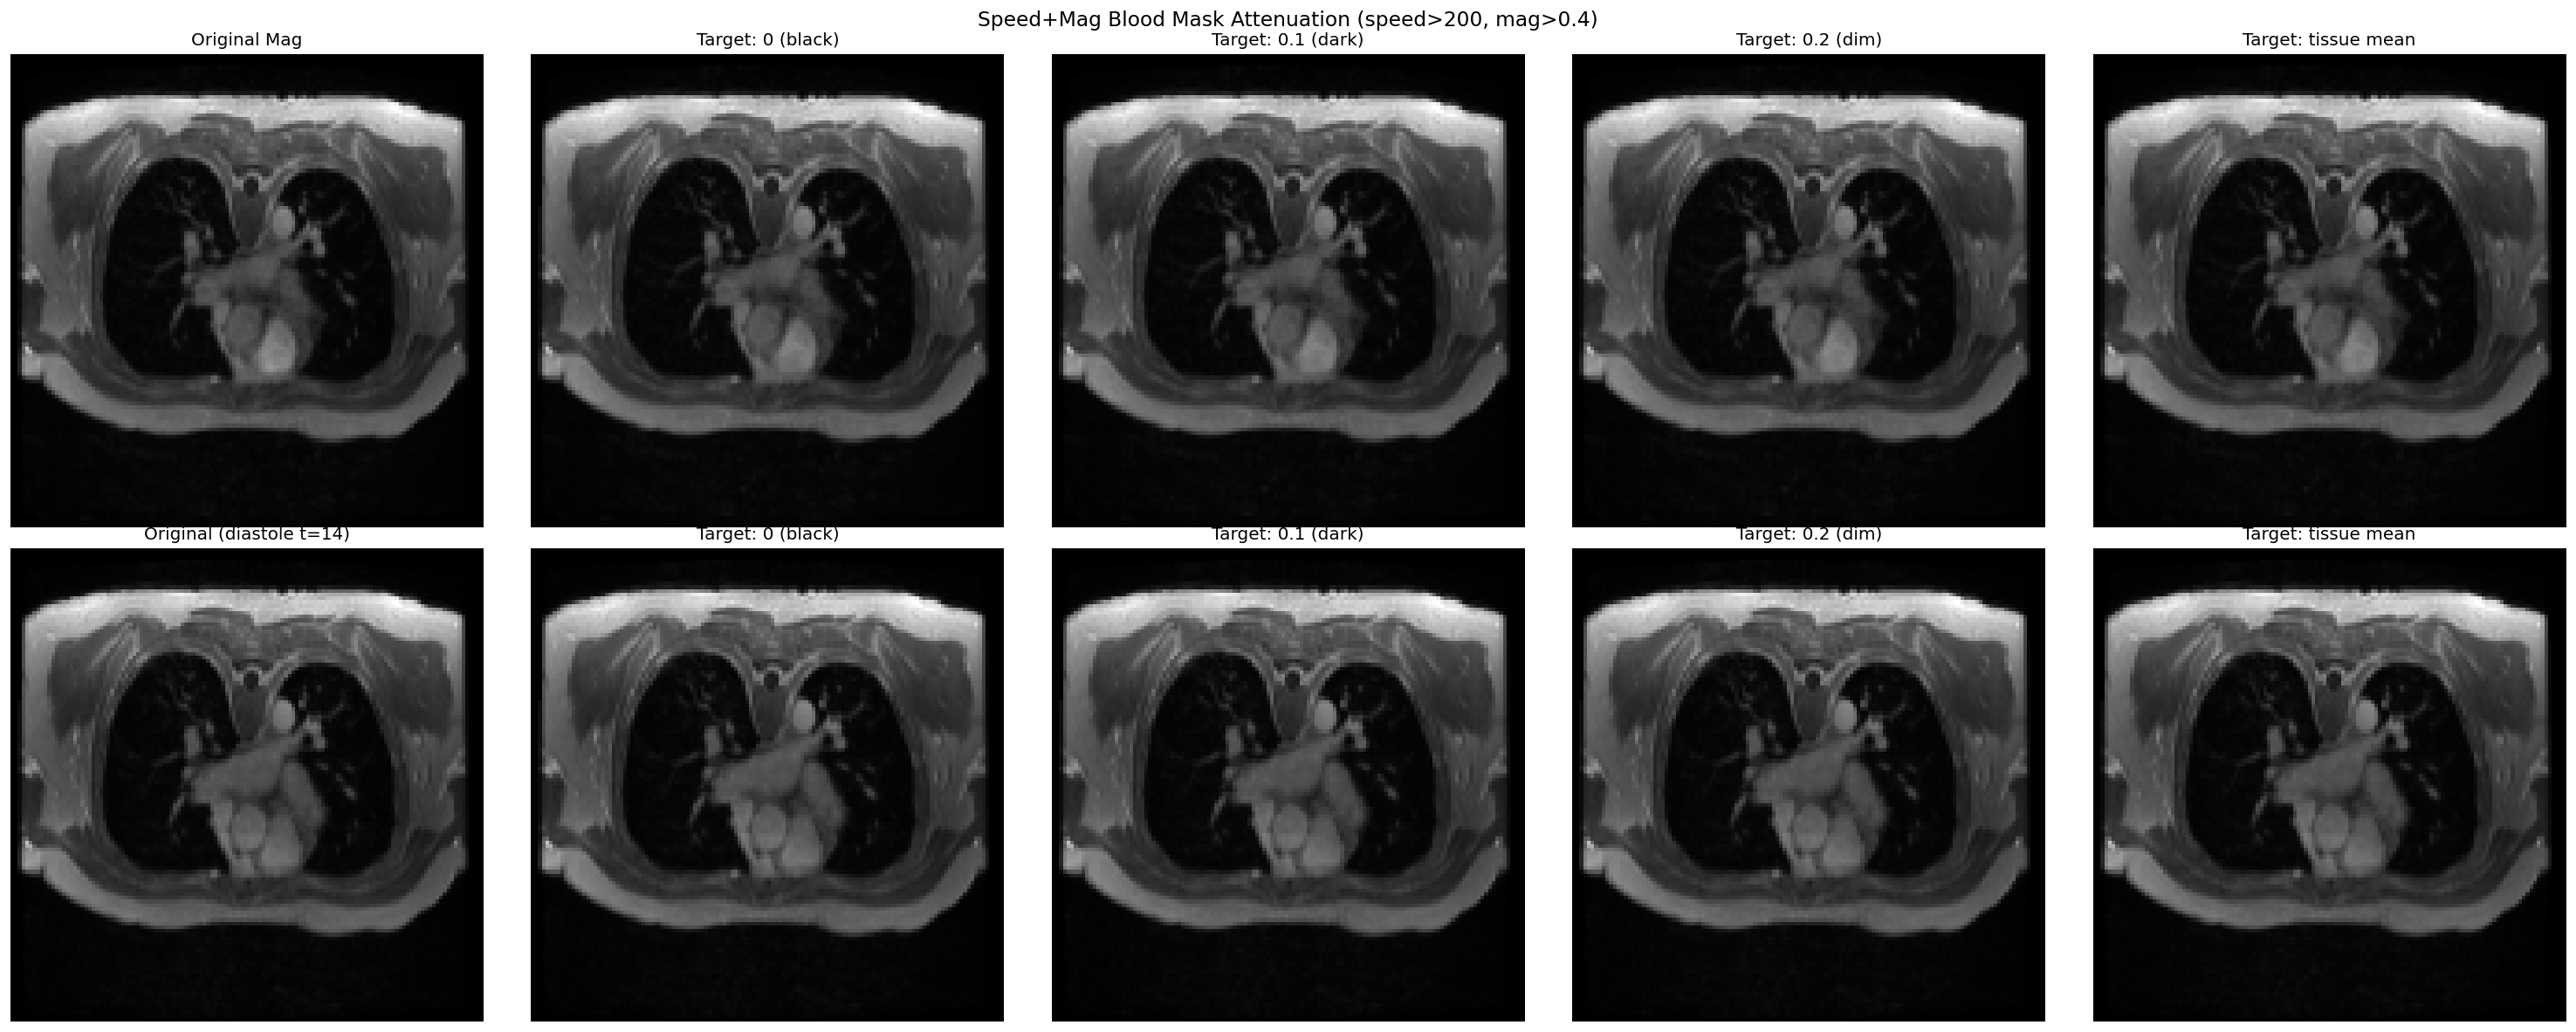

Systole blood mask: 2.4% of volume
Diastole blood mask: 2.2% of volume


In [112]:
# --- Adjust these based on what looked best above ---
SPEED_THR = 200   # mm/s - tune this
MAG_THR = 0.4     # mag threshold for bright blood

blood_mask = ((speed_sys > SPEED_THR) & (mag_sys > MAG_THR)).float()
blood_mask = gaussian_smooth_3d(blood_mask, sigma=1.5)

tissue_mean = local_tissue_mean(mag_sys, kernel_sigma=8.0)
targets = [0.0, 0.1, 0.2, tissue_mean]
target_labels = ['0 (black)', '0.1 (dark)', '0.2 (dim)', 'tissue mean']

fig, axes = plt.subplots(2, len(targets) + 1, figsize=(5 * (len(targets) + 1), 10))

# Row 0: the mask and attenuation results
axes[0, 0].imshow(mag_sys[0, :, :, AX_SLICE].T, cmap='gray', origin='lower')
axes[0, 0].set_title('Original Mag')
for j, (tgt, lbl) in enumerate(zip(targets, target_labels)):
    if isinstance(tgt, torch.Tensor):
        result = mag_sys * (1 - blood_mask) + tgt * blood_mask
    else:
        result = mag_sys * (1 - blood_mask) + tgt * blood_mask
    axes[0, j + 1].imshow(result[0, :, :, AX_SLICE].T, cmap='gray', origin='lower')
    axes[0, j + 1].set_title(f'Target: {lbl}')

# Row 1: same for diastole
speed_mask_dia = ((speed_dia > SPEED_THR) & (mag_dia > MAG_THR)).float()
speed_mask_dia = gaussian_smooth_3d(speed_mask_dia, sigma=1.5)
tissue_mean_dia = local_tissue_mean(mag_dia, kernel_sigma=8.0)
targets_dia = [0.0, 0.1, 0.2, tissue_mean_dia]

axes[1, 0].imshow(mag_dia[0, :, :, AX_SLICE].T, cmap='gray', origin='lower')
axes[1, 0].set_title(f'Original (diastole t={DIASTOLIC_TP})')
for j, (tgt, lbl) in enumerate(zip(targets_dia, target_labels)):
    if isinstance(tgt, torch.Tensor):
        result = mag_dia * (1 - speed_mask_dia) + tgt * speed_mask_dia
    else:
        result = mag_dia * (1 - speed_mask_dia) + tgt * speed_mask_dia
    axes[1, j + 1].imshow(result[0, :, :, AX_SLICE].T, cmap='gray', origin='lower')
    axes[1, j + 1].set_title(f'Target: {lbl}')

for ax in axes.flat:
    ax.axis('off')
axes[0, 0].set_ylabel('Systole', fontsize=12)
axes[1, 0].set_ylabel('Diastole', fontsize=12)
plt.suptitle(f'Speed+Mag Blood Mask Attenuation (speed>{SPEED_THR}, mag>{MAG_THR})', fontsize=14)
plt.tight_layout()
plt.show()

print(f"Systole blood mask: {(blood_mask > 0.01).float().mean().item()*100:.1f}% of volume")
print(f"Diastole blood mask: {(speed_mask_dia > 0.01).float().mean().item()*100:.1f}% of volume")

### Approach B: Blend Toward Local Tissue Mean

`result = mag * (1 - alpha * speed_mask) + tissue_mean * alpha * speed_mask`

Blood signal blends toward the local tissue intensity. This makes blood
"disappear" into the surrounding tissue - simulating contrast removal.

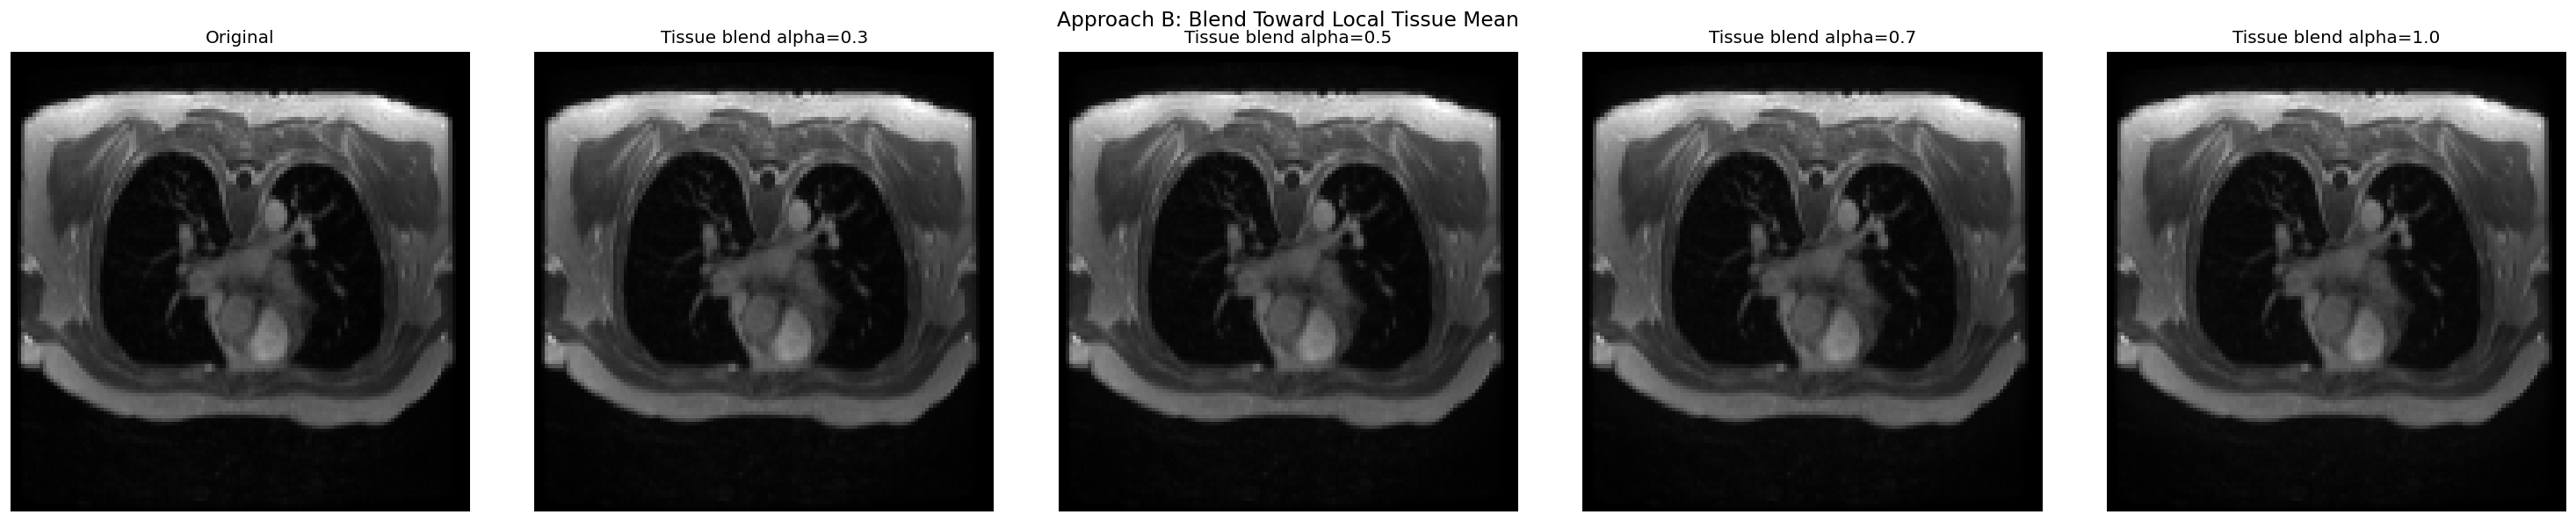

In [113]:
fig, axes = plt.subplots(1, len(alphas) + 1, figsize=(5 * (len(alphas) + 1), 5))
axes[0].imshow(mag_sys[0, :, :, AX_SLICE].T, cmap='gray', origin='lower')
axes[0].set_title('Original')

for j, alpha in enumerate(alphas):
    mask = alpha * speed_mask_sys
    result = mag_sys * (1 - mask) + tissue_mean_sys * mask
    axes[j + 1].imshow(result[0, :, :, AX_SLICE].T, cmap='gray', origin='lower')
    axes[j + 1].set_title(f'Tissue blend alpha={alpha}')

for ax in axes:
    ax.axis('off')
plt.suptitle('Approach B: Blend Toward Local Tissue Mean', fontsize=14)
plt.tight_layout()
plt.show()

### Approach C: Blend Toward Dark (Configurable Target)

`result = mag * (1 - alpha * speed_mask) + target * alpha * speed_mask`

Same blending but toward a configurable target value. Low target = dark blood,
mid target = tissue-like blood. Sweep target from 0 to 0.4.

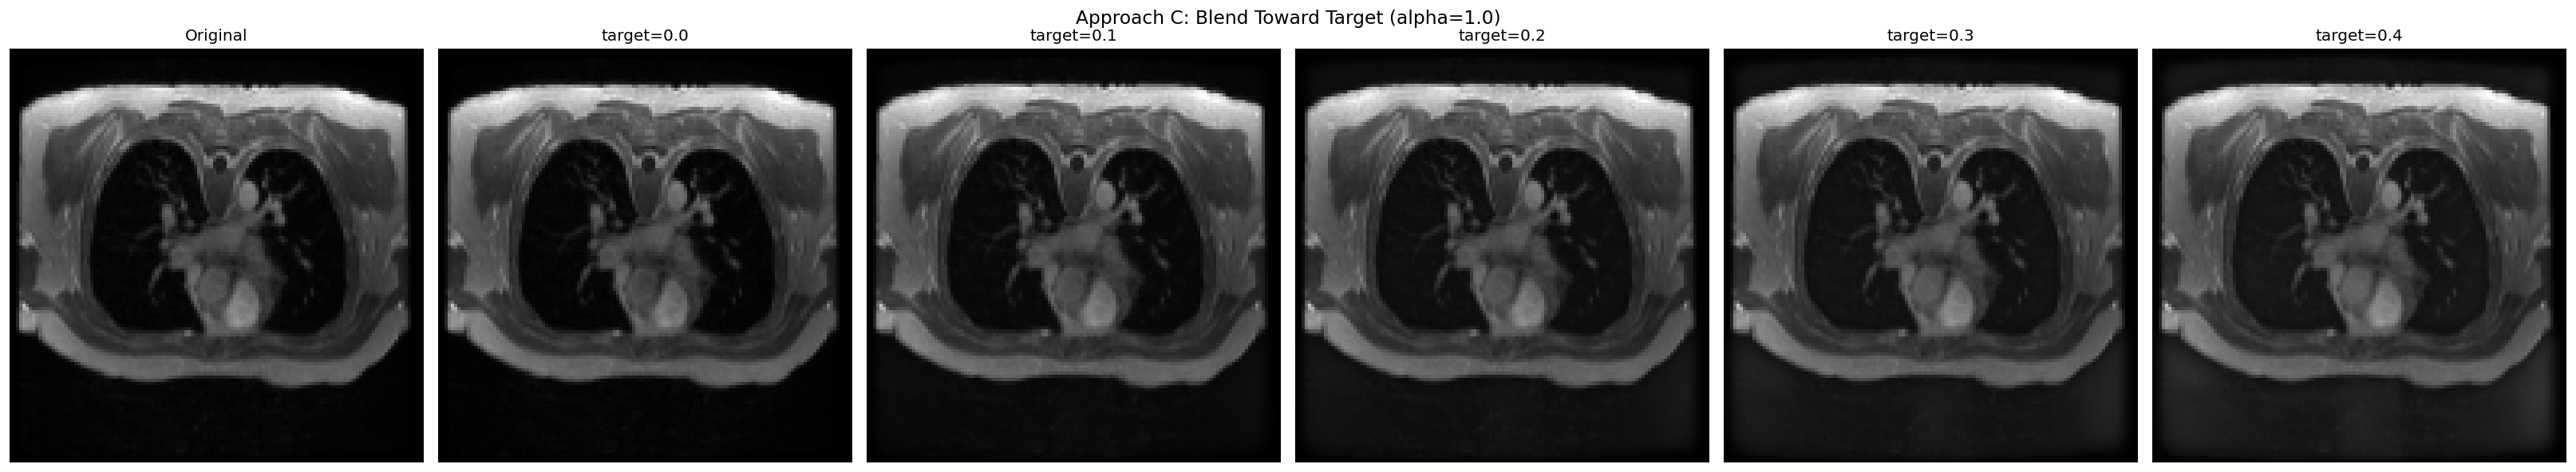

In [114]:
targets = [0.0, 0.1, 0.2, 0.3, 0.4]
alpha = 1.0

fig, axes = plt.subplots(1, len(targets) + 1, figsize=(4.5 * (len(targets) + 1), 5))
axes[0].imshow(mag_sys[0, :, :, AX_SLICE].T, cmap='gray', origin='lower')
axes[0].set_title('Original')

for j, target in enumerate(targets):
    mask = alpha * speed_mask_sys
    result = mag_sys * (1 - mask) + target * mask
    axes[j + 1].imshow(result[0, :, :, AX_SLICE].T, cmap='gray', origin='lower')
    axes[j + 1].set_title(f'target={target}')

for ax in axes:
    ax.axis('off')
plt.suptitle(f'Approach C: Blend Toward Target (alpha={alpha})', fontsize=14)
plt.tight_layout()
plt.show()

### Approach D: Combined - Randomise the Target

During training, randomly sample the target between 0 and the local tissue
mean. This gives the model a range from "dark blood" to "iso-intense blood".

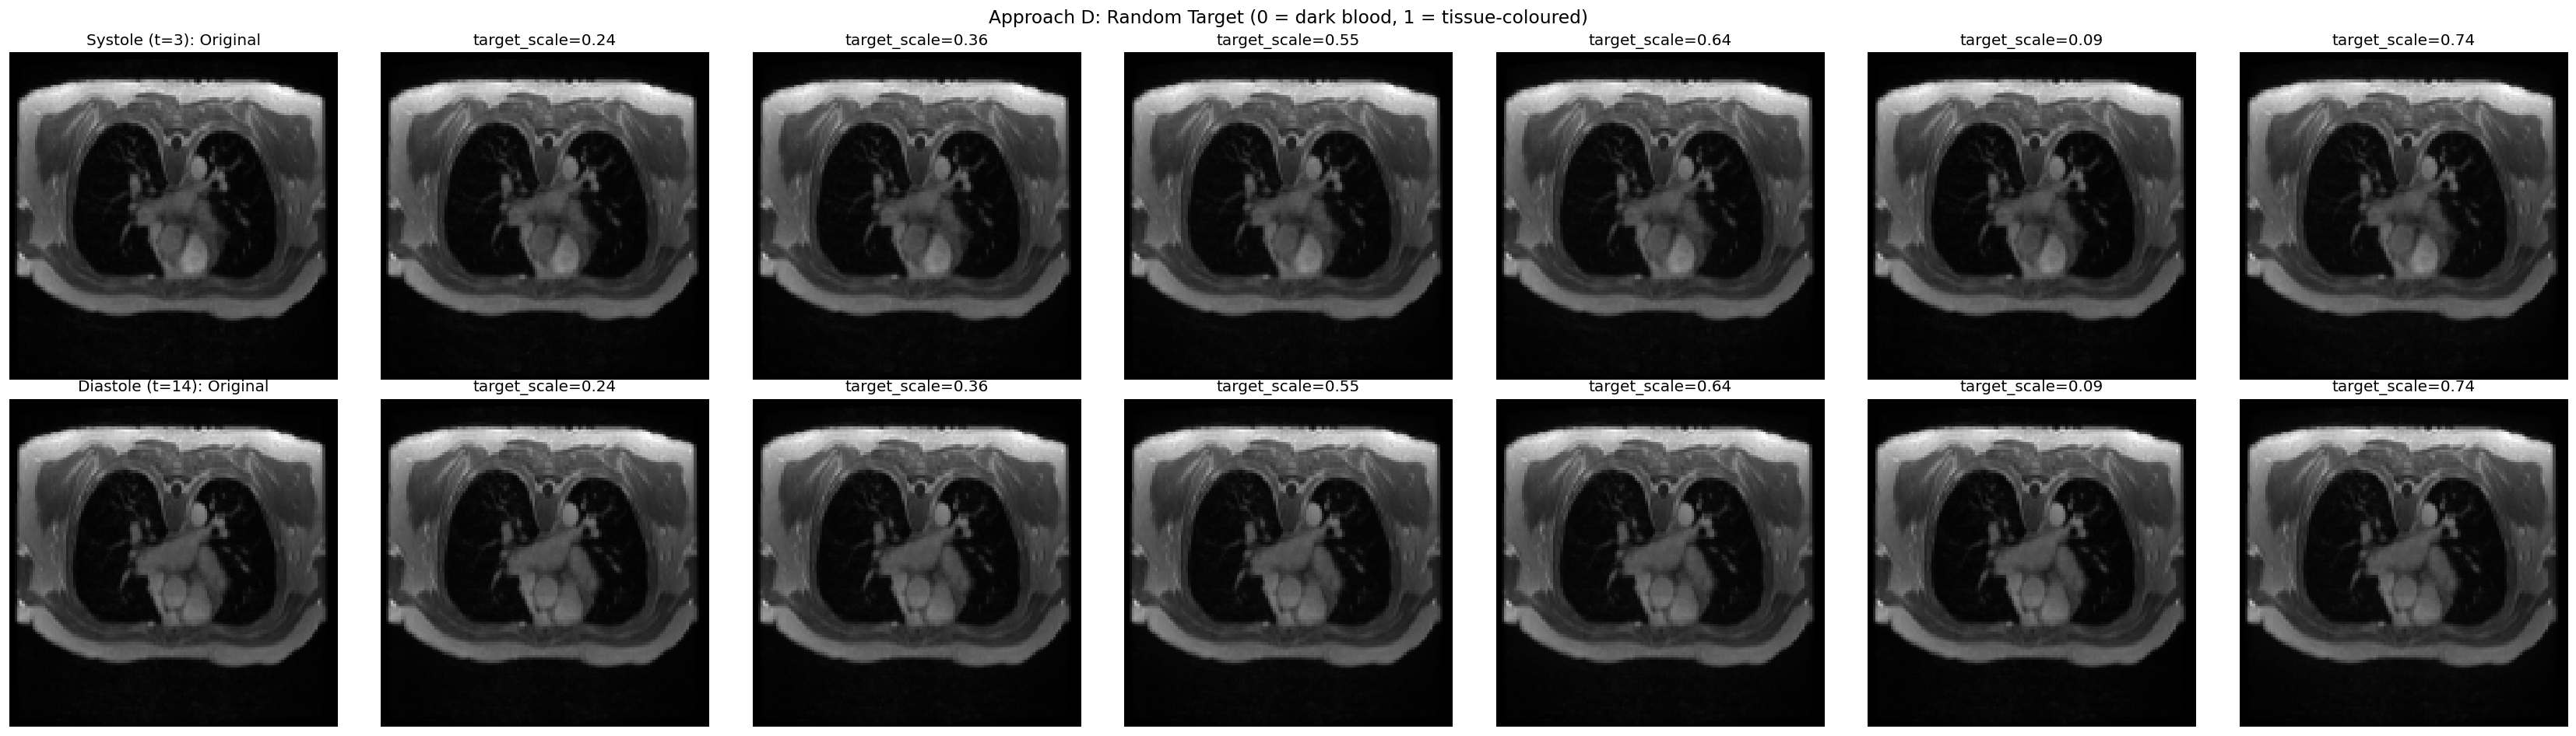

In [115]:
import random

alpha = 0.85
n_samples = 6

fig, axes = plt.subplots(2, n_samples + 1, figsize=(4 * (n_samples + 1), 8))

for row, (mag, speed, label) in enumerate([
    (mag_sys, speed_sys, f'Systole (t={SYSTOLIC_TP})'),
    (mag_dia, speed_dia, f'Diastole (t={DIASTOLIC_TP})'),
]):
    smask = compute_speed_mask(speed, smooth_sigma=2.0)
    tmean = local_tissue_mean(mag, kernel_sigma=8.0)

    axes[row, 0].imshow(mag[0, :, :, AX_SLICE].T, cmap='gray', origin='lower')
    axes[row, 0].set_title(f'{label}: Original')

    for j in range(n_samples):
        random.seed(j * 13 + 3)
        # Random blend factor between dark blood (0) and tissue-coloured blood
        target_scale = random.uniform(0.0, 1.0)
        target = tmean * target_scale
        mask = alpha * smask
        result = mag * (1 - mask) + target * mask
        axes[row, j + 1].imshow(result[0, :, :, AX_SLICE].T, cmap='gray', origin='lower')
        axes[row, j + 1].set_title(f'target_scale={target_scale:.2f}')

for ax in axes.flat:
    ax.axis('off')
plt.suptitle('Approach D: Random Target (0 = dark blood, 1 = tissue-coloured)', fontsize=14)
plt.tight_layout()
plt.show()

---
## Step 6: Body Mask

Show the body mask and its effect on the speed mask.

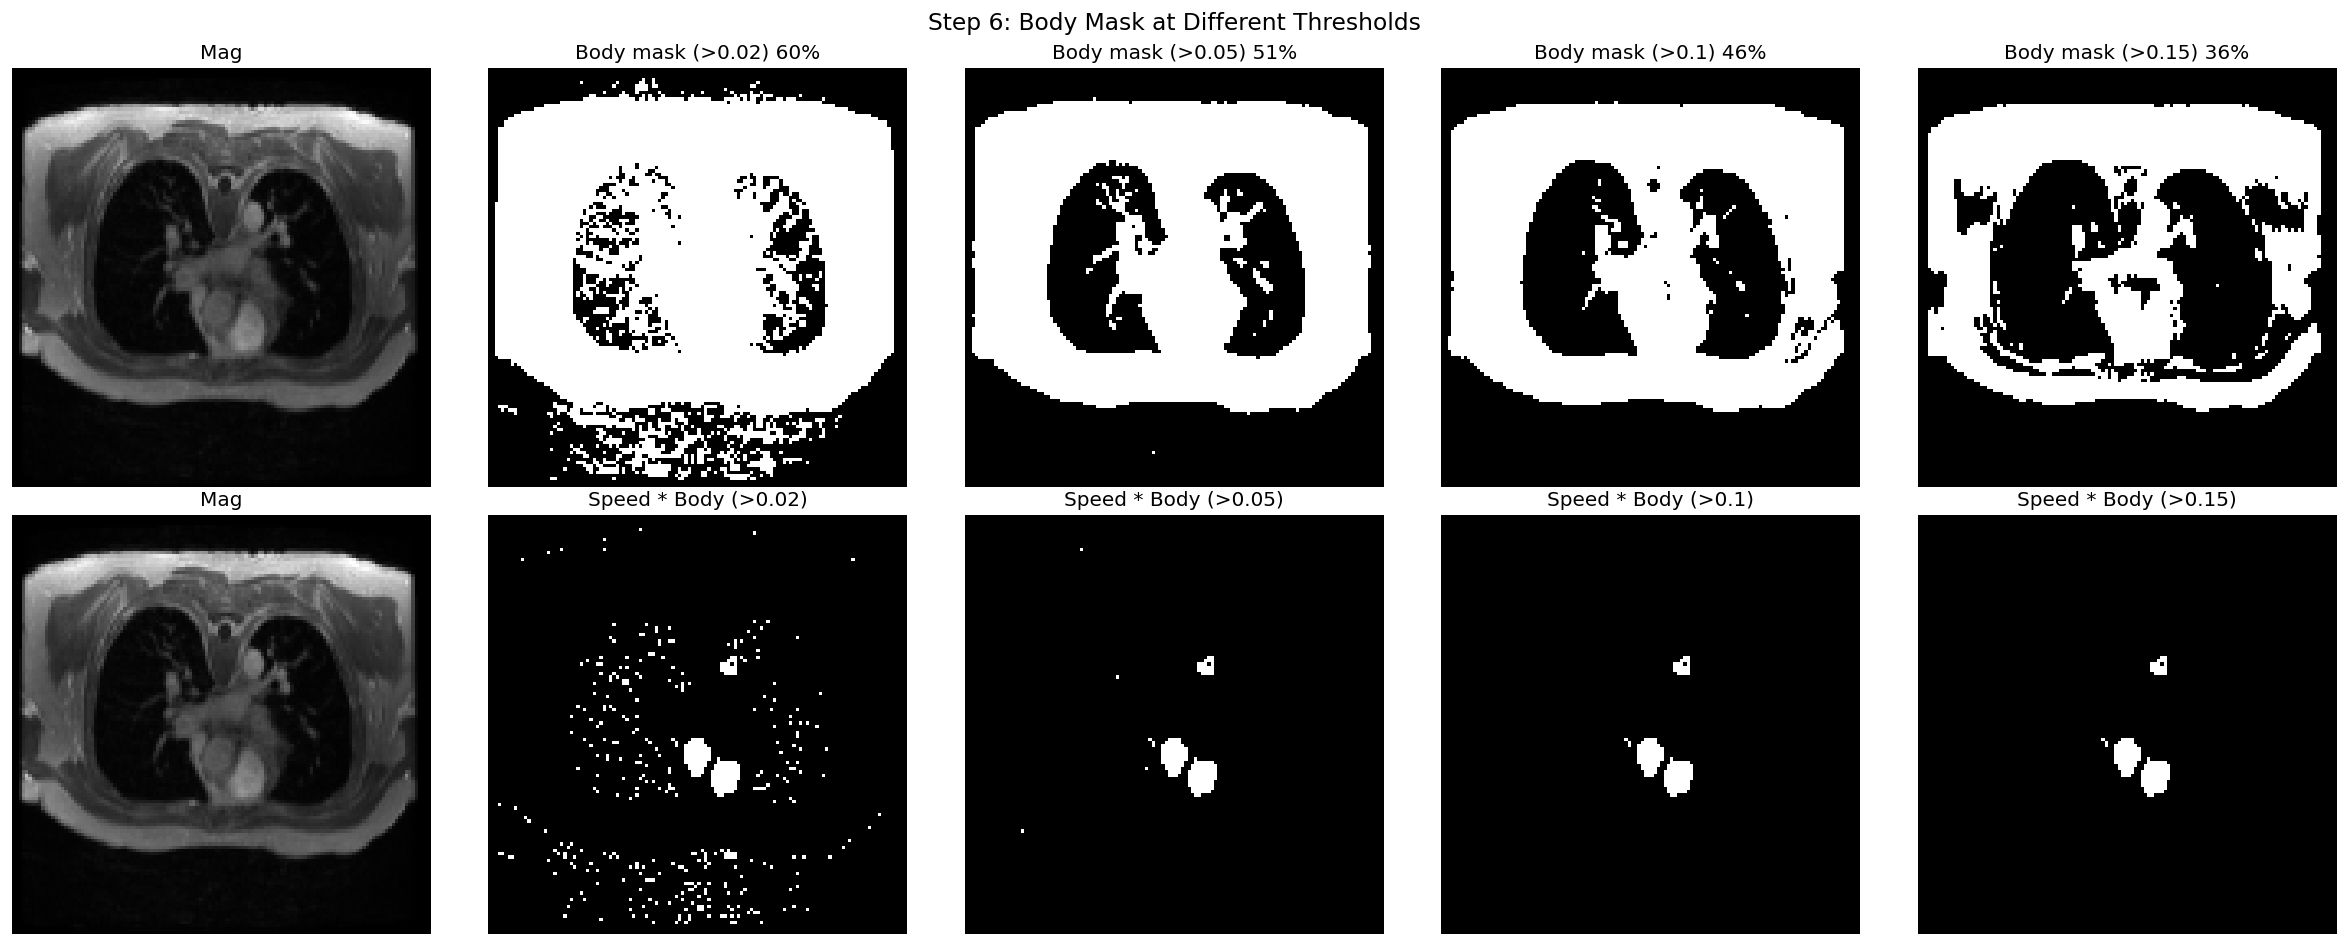

In [116]:
air_thresholds = [0.02, 0.05, 0.10, 0.15]

fig, axes = plt.subplots(2, len(air_thresholds) + 1, figsize=(4 * (len(air_thresholds) + 1), 8))

axes[0, 0].imshow(mag_sys[0, :, :, AX_SLICE].T, cmap='gray', origin='lower')
axes[0, 0].set_title('Mag')
axes[1, 0].imshow(mag_sys[0, :, :, AX_SLICE].T, cmap='gray', origin='lower')
axes[1, 0].set_title('Mag')

for j, at in enumerate(air_thresholds):
    body = (mag_sys > at).float()
    pct = body.mean().item() * 100
    axes[0, j + 1].imshow(body[0, :, :, AX_SLICE].T, cmap='gray', origin='lower')
    axes[0, j + 1].set_title(f'Body mask (>{at}) {pct:.0f}%')

    # Speed mask * body mask
    speed_mask = (norm_speed_sys > 0.15).float()
    combined = speed_mask * body
    axes[1, j + 1].imshow(combined[0, :, :, AX_SLICE].T, cmap='gray', origin='lower')
    axes[1, j + 1].set_title(f'Speed * Body (>{at})')

for ax in axes.flat:
    ax.axis('off')
plt.suptitle('Step 6: Body Mask at Different Thresholds', fontsize=14)
plt.tight_layout()
plt.show()

---
## Step 7: Full Pipeline - Putting It Together

Apply the complete pipeline: normalise speed -> threshold -> smooth -> body mask -> invert.
Show each intermediate stage.

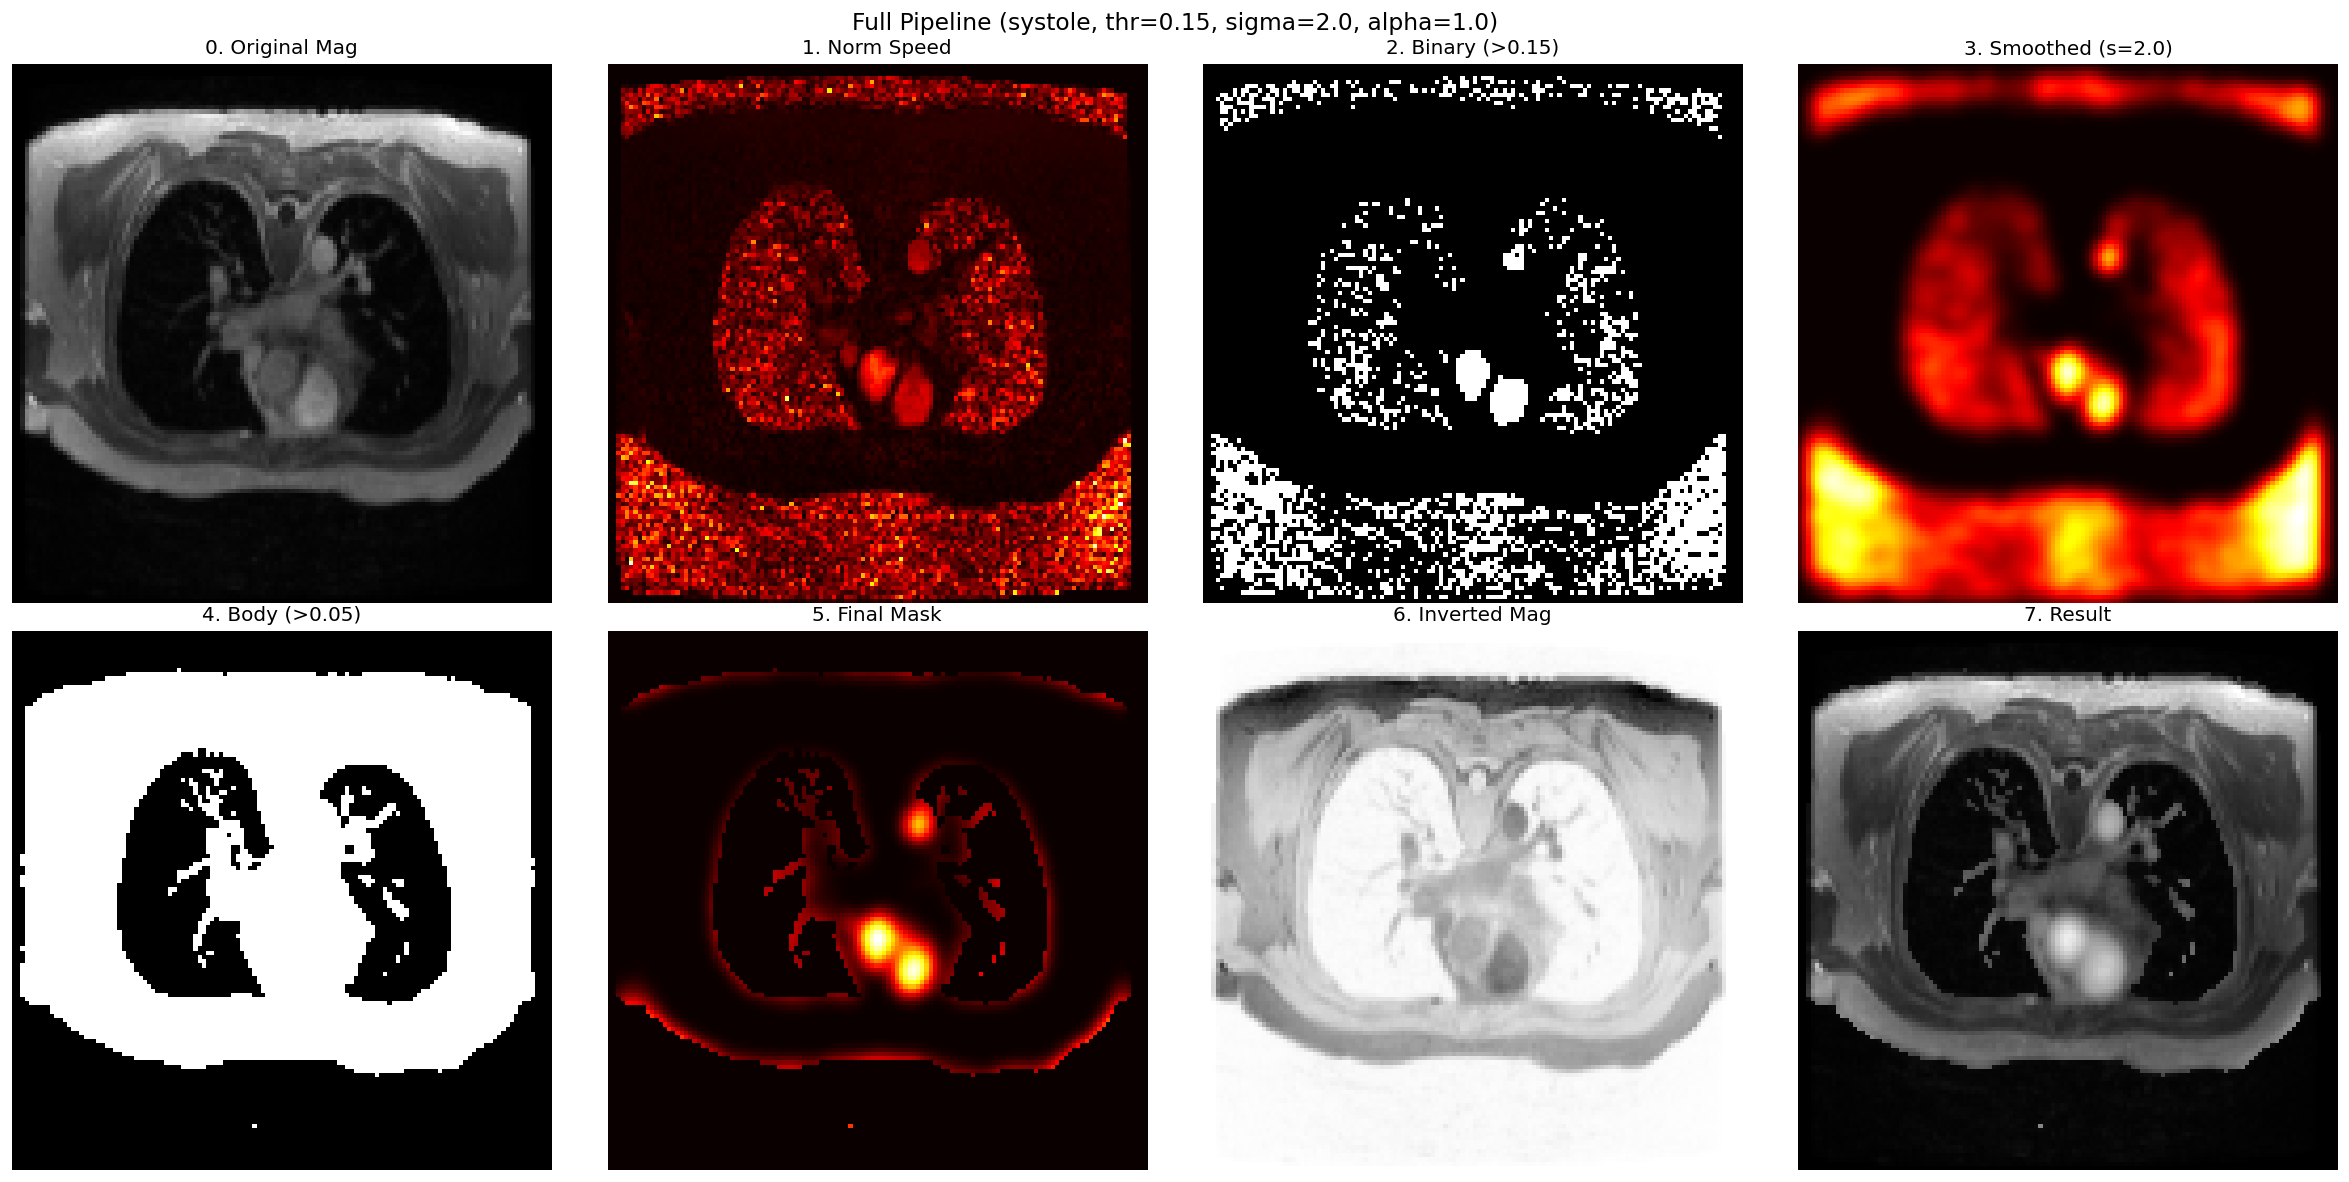

In [117]:
SPEED_THR = 0.15
SMOOTH_SIGMA = 2.0
BODY_THR = 0.05
ALPHA = 1.0

stages = {}

# Stage 1: normalised speed
stages['1_norm_speed'] = norm_speed_sys

# Stage 2: binary threshold
stages['2_binary_mask'] = (norm_speed_sys > SPEED_THR).float()

# Stage 3: smoothed mask
stages['3_smoothed_mask'] = gaussian_smooth_3d(stages['2_binary_mask'], sigma=SMOOTH_SIGMA)

# Stage 4: body mask
stages['4_body_mask'] = (mag_sys > BODY_THR).float()

# Stage 5: final mask (smoothed * body)
stages['5_final_mask'] = stages['3_smoothed_mask'] * stages['4_body_mask']

# Stage 6: inverted image (1 - mag)
stages['6_inverted'] = 1.0 - mag_sys

# Stage 7: alpha-blended result
final_mask = stages['5_final_mask']
stages['7_result'] = mag_sys * (1 - final_mask * ALPHA) + stages['6_inverted'] * (final_mask * ALPHA)

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
plot_items = [
    ('1_norm_speed', 'hot', '1. Norm Speed'),
    ('2_binary_mask', 'gray', f'2. Binary (>{SPEED_THR})'),
    ('3_smoothed_mask', 'hot', f'3. Smoothed (s={SMOOTH_SIGMA})'),
    ('4_body_mask', 'gray', f'4. Body (>{BODY_THR})'),
    ('5_final_mask', 'hot', '5. Final Mask'),
    ('6_inverted', 'gray', '6. Inverted Mag'),
    ('7_result', 'gray', '7. Result'),
]

# Also show original mag
axes[0, 0].imshow(mag_sys[0, :, :, AX_SLICE].T, cmap='gray', origin='lower')
axes[0, 0].set_title('0. Original Mag')
axes[0, 0].axis('off')

for i, (key, cmap, title) in enumerate(plot_items):
    row = (i + 1) // 4
    col = (i + 1) % 4
    im = axes[row, col].imshow(stages[key][0, :, :, AX_SLICE].T, cmap=cmap, origin='lower')
    axes[row, col].set_title(title)
    axes[row, col].axis('off')

plt.suptitle(f'Full Pipeline (systole, thr={SPEED_THR}, sigma={SMOOTH_SIGMA}, alpha={ALPHA})', fontsize=14)
plt.tight_layout()
plt.show()

---
## Step 8: Soft Alpha Pipeline (Speed as Continuous Alpha)

Instead of a binary threshold, use normalised speed directly as the
spatially-varying alpha. Break down each stage.

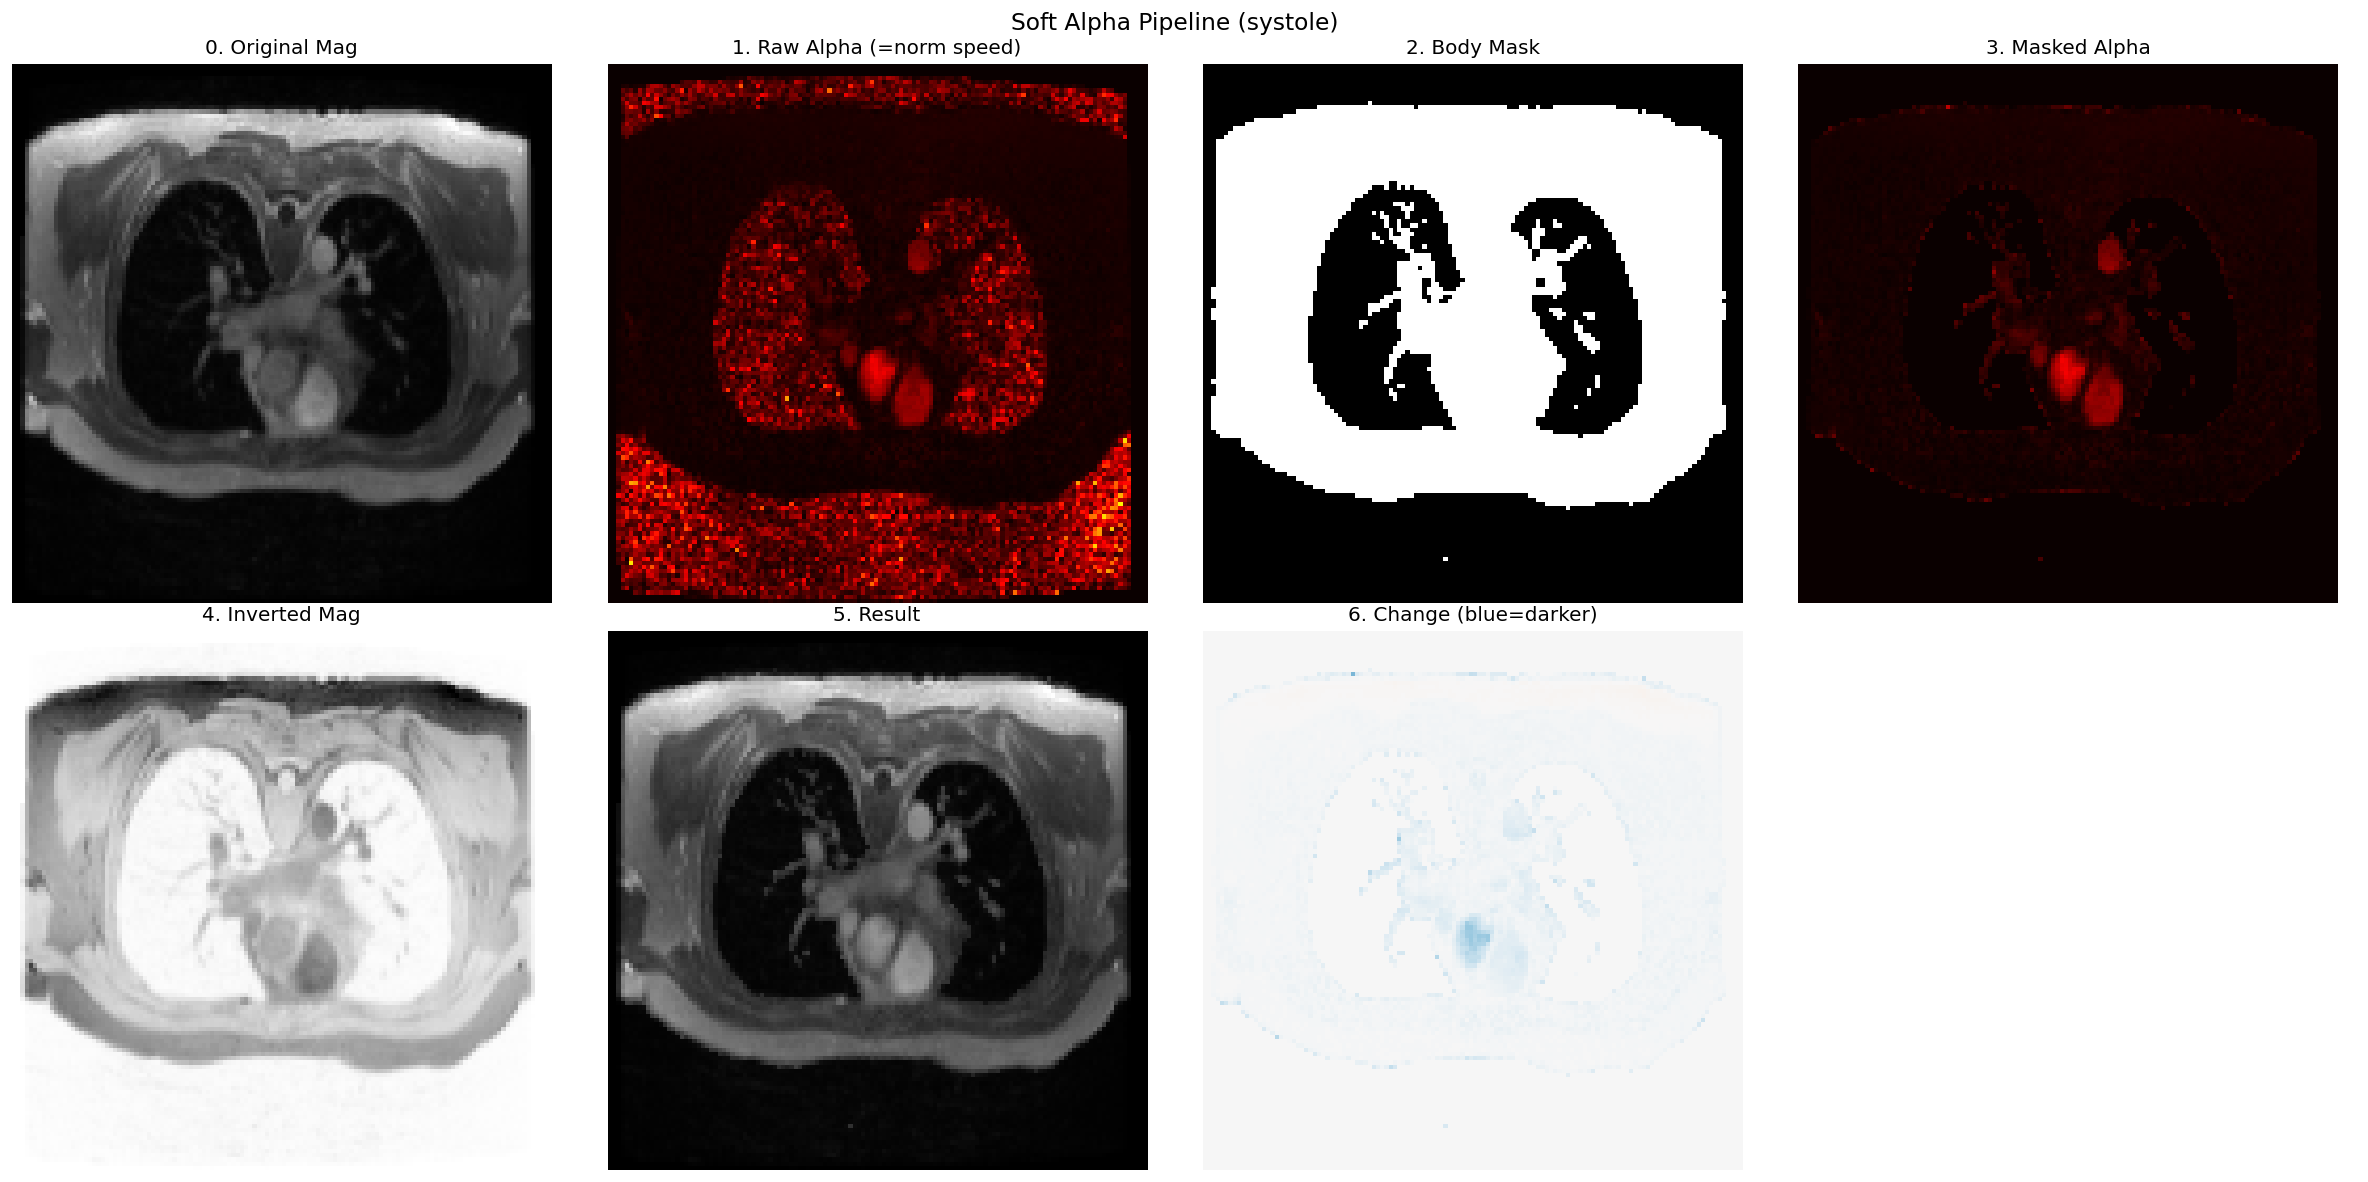

In [118]:
BODY_THR = 0.05
ALPHA_SCALE = 1.0

soft_stages = {}

# Stage 1: normalised speed = alpha map
soft_stages['1_alpha_map_raw'] = norm_speed_sys * ALPHA_SCALE

# Stage 2: body mask
body = (mag_sys > BODY_THR).float()
soft_stages['2_body_mask'] = body

# Stage 3: masked alpha map
soft_stages['3_alpha_masked'] = soft_stages['1_alpha_map_raw'] * body

# Stage 4: inverted mag
soft_stages['4_inverted'] = 1.0 - mag_sys

# Stage 5: result
alpha = soft_stages['3_alpha_masked']
soft_stages['5_result'] = mag_sys * (1 - alpha) + soft_stages['4_inverted'] * alpha

# Stage 6: change map (result - original)
soft_stages['6_change'] = soft_stages['5_result'] - mag_sys

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
soft_items = [
    (mag_sys, 'gray', '0. Original Mag', None),
    (soft_stages['1_alpha_map_raw'], 'hot', '1. Raw Alpha (=norm speed)', (0, 1)),
    (soft_stages['2_body_mask'], 'gray', '2. Body Mask', None),
    (soft_stages['3_alpha_masked'], 'hot', '3. Masked Alpha', (0, 1)),
    (soft_stages['4_inverted'], 'gray', '4. Inverted Mag', None),
    (soft_stages['5_result'], 'gray', '5. Result', None),
    (soft_stages['6_change'], 'RdBu', '6. Change (blue=darker)', (-0.5, 0.5)),
]

for i, (data, cmap, title, vlim) in enumerate(soft_items):
    row = i // 4
    col = i % 4
    kwargs = {'cmap': cmap, 'origin': 'lower'}
    if vlim:
        kwargs['vmin'], kwargs['vmax'] = vlim
    im = axes[row, col].imshow(data[0, :, :, AX_SLICE].T, **kwargs)
    axes[row, col].set_title(title)
    axes[row, col].axis('off')

# Last cell is empty
axes[1, 3].axis('off')

plt.suptitle('Soft Alpha Pipeline (systole)', fontsize=14)
plt.tight_layout()
plt.show()

---
## Step 9: Same Pipeline on Diastole

Repeat the full pipeline breakdown for the diastolic timepoint to see
how the low-speed problem manifests at each stage.

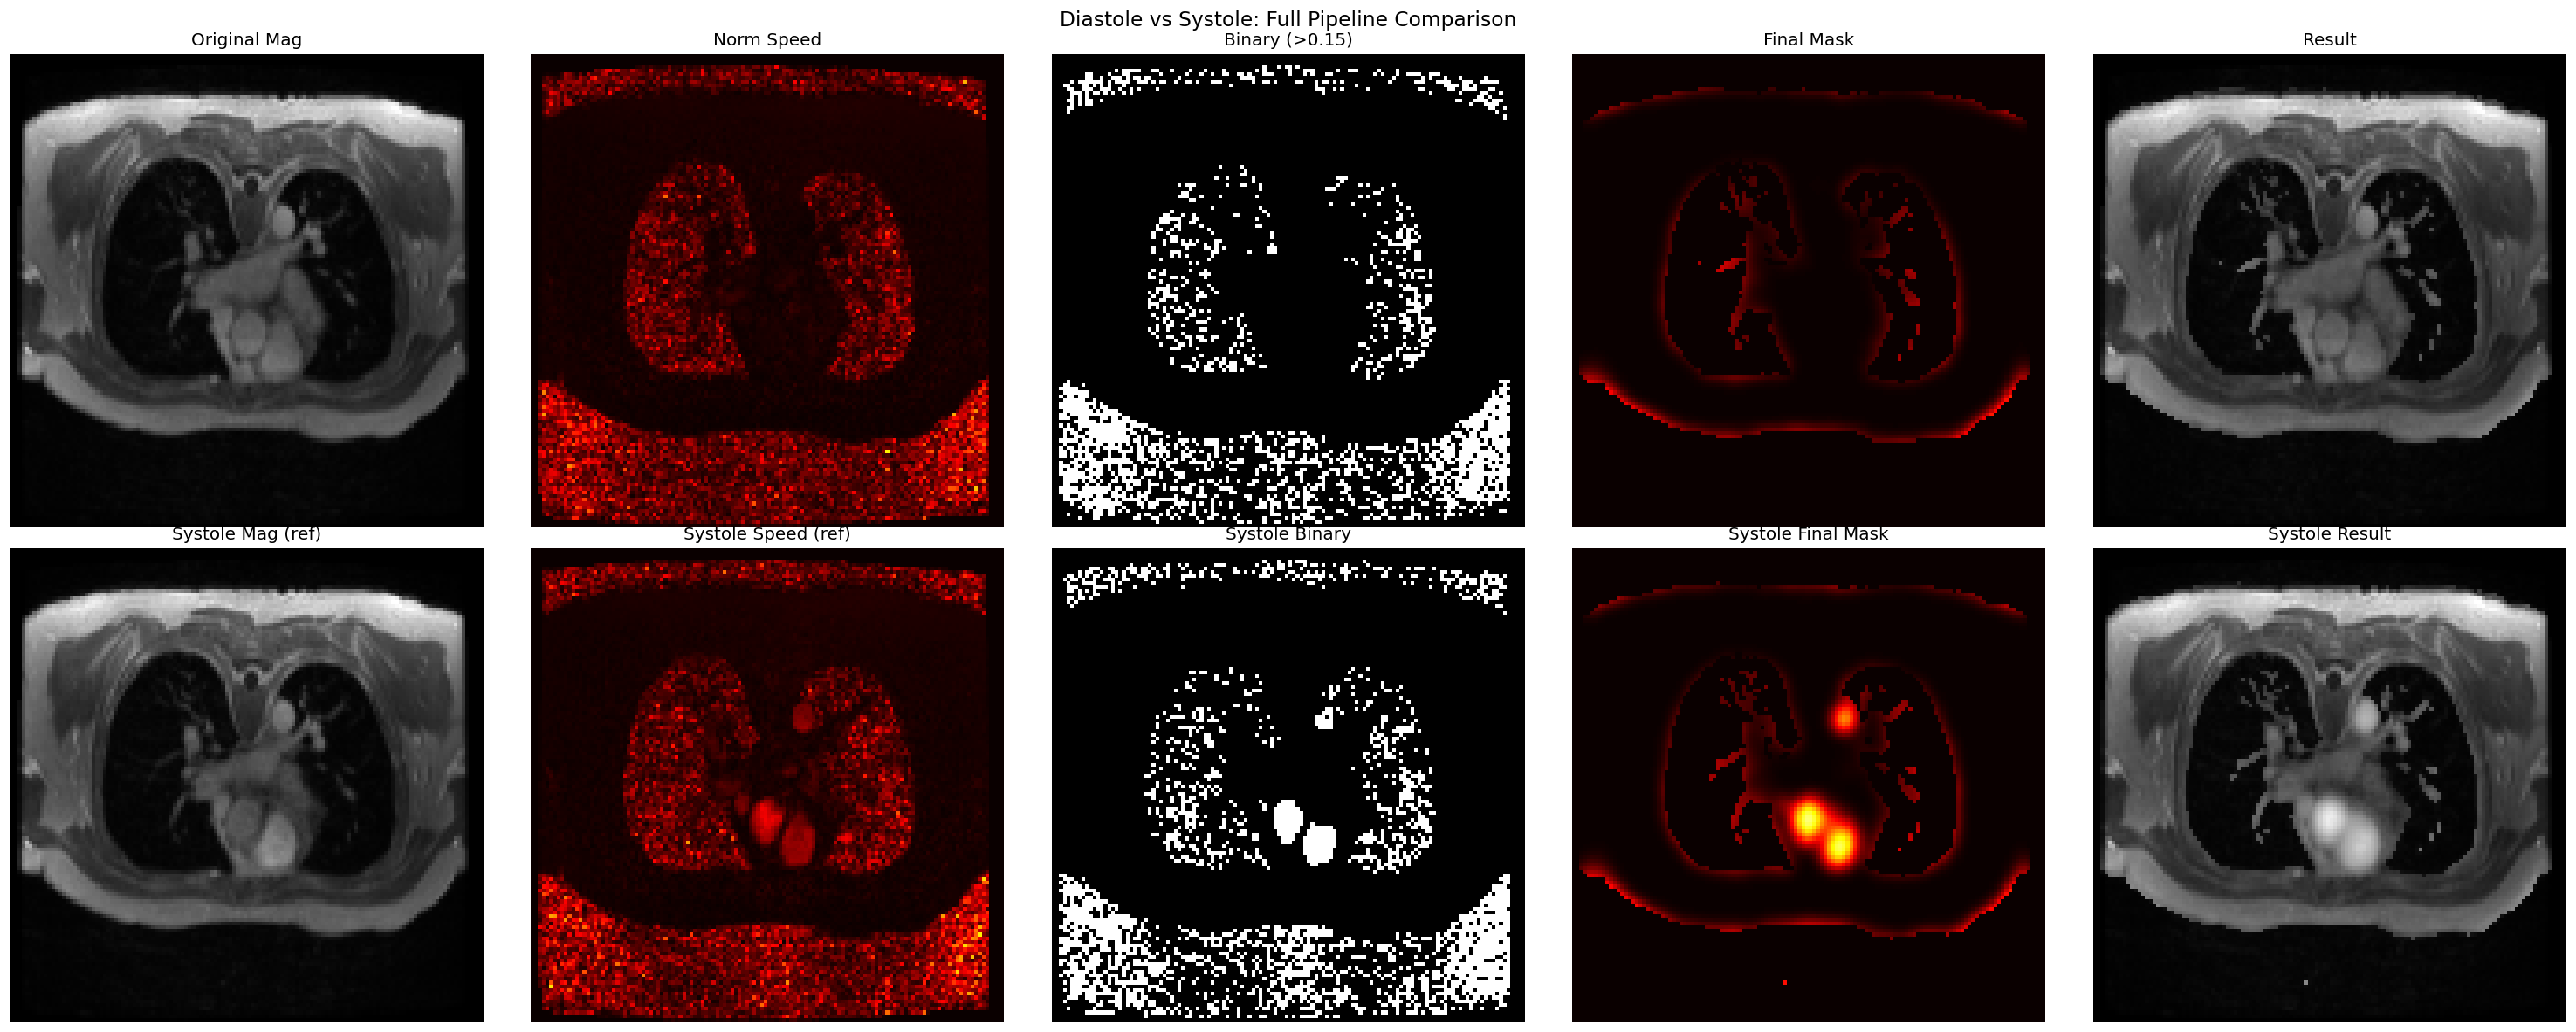

In [119]:
# Threshold pipeline - diastole
SPEED_THR = 0.15
SMOOTH_SIGMA = 2.0
BODY_THR = 0.05

dia_stages = {}
dia_stages['1_norm_speed'] = norm_speed_dia
dia_stages['2_binary_mask'] = (norm_speed_dia > SPEED_THR).float()
dia_stages['3_smoothed_mask'] = gaussian_smooth_3d(dia_stages['2_binary_mask'], sigma=SMOOTH_SIGMA)
dia_stages['4_body_mask'] = (mag_dia > BODY_THR).float()
dia_stages['5_final_mask'] = dia_stages['3_smoothed_mask'] * dia_stages['4_body_mask']
dia_stages['6_inverted'] = 1.0 - mag_dia
fm = dia_stages['5_final_mask']
dia_stages['7_result'] = mag_dia * (1 - fm) + dia_stages['6_inverted'] * fm
dia_stages['8_change'] = dia_stages['7_result'] - mag_dia

fig, axes = plt.subplots(2, 5, figsize=(25, 10))
dia_items = [
    (mag_dia, 'gray', 'Original Mag'),
    (dia_stages['1_norm_speed'], 'hot', 'Norm Speed'),
    (dia_stages['2_binary_mask'], 'gray', f'Binary (>{SPEED_THR})'),
    (dia_stages['5_final_mask'], 'hot', 'Final Mask'),
    (dia_stages['7_result'], 'gray', 'Result'),
    (mag_sys, 'gray', 'Systole Mag (ref)'),
    (norm_speed_sys, 'hot', 'Systole Speed (ref)'),
    ((norm_speed_sys > SPEED_THR).float(), 'gray', f'Systole Binary'),
    (stages['5_final_mask'], 'hot', 'Systole Final Mask'),
    (stages['7_result'], 'gray', 'Systole Result'),
]

for i, (data, cmap, title) in enumerate(dia_items):
    row = i // 5
    col = i % 5
    kwargs = {'cmap': cmap, 'origin': 'lower'}
    if 'hot' in cmap:
        kwargs['vmin'], kwargs['vmax'] = 0, 1
    axes[row, col].imshow(data[0, :, :, AX_SLICE].T, **kwargs)
    axes[row, col].set_title(title)
    axes[row, col].axis('off')

axes[0, 0].set_ylabel('Diastole', fontsize=12)
axes[1, 0].set_ylabel('Systole', fontsize=12)
plt.suptitle('Diastole vs Systole: Full Pipeline Comparison', fontsize=14)
plt.tight_layout()
plt.show()